
SAE (Sparse Autoencoder - denso) para cavity_refinado

O que este script faz:
- Lê U (Ux, Uy) do OpenFOAM em múltiplos timesteps
- Interpola para uma grade 2D regular (imagem) via griddata
- Constrói vetor por snapshot: flatten([Ux_grid, Uy_grid]) -> (ny*nx*2,)
- Split temporal (train/val) SEM embaralhar
- Normalização por feature (apenas estatísticas do treino)
- Clipping robusto após normalizar
- Treina SAE denso com penalidade L1 no latente (esparsidade)
- Callbacks: EarlyStopping, ReduceLROnPlateau, Checkpoint
- Diagnósticos + 7+ análises:
  (1) loss/val_loss
  (2) generalization gap
  (3) overfit score (gap/|val|)
  (4) MSE por snapshot (train vs val)
  (5) relL2 por snapshot (train vs val)
  (6) histogramas relL2 train/val
  (7) outliers topK com imagens (Ux/Uy true|recon|err)
  (8) relL2 no físico (desnormalizado)
  (9) latentes z(t) salvos (train/val)
- Salva: modelos, normalização, latentes, métricas .npz, figuras



In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Tuple, Dict, Any

import os
import re
os.environ["MPLBACKEND"] = "Agg"

import numpy as np
import tensorflow as tf
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
plt.switch_backend("Agg")

from scipy.interpolate import griddata
from fluidfoam import readmesh, readfield
from IPython.display import display


2026-09-28 09:33:44.441369: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Config + Paths

In [2]:
@dataclass
class SAEConfig:
    case_dir: Path
    out_dir: Path

    nx: int = 48
    ny: int = 48
    padding: float = 0.0
    interp_method: str = "linear"
    # Configuração leve para computadores com pouca memória.
    # Cavity não possui alpha.water/p_rgh; usa Ux, Uy, p, T e k.
    field_names: tuple[str, ...] = ("U", "p", "T", "k")
    n_timesteps: int | None = None
    time_stride: int = 10

    train_ratio: float = 0.80

    latent_dim: int = 8
    hidden: list[int] | None = None
    lr: float = 5e-5
    epochs: int = 150
    batch: int = 32
    shuffle: bool = True

    l1_latent: float = 0.0#1e-7
    dropout: float = 0.0
    clip_zscore: float | None = 4.0
    use_huber: bool = True
    huber_delta: float = 1.0

    early_patience: int = 20
    plateau_patience: int = 8

    outlier_topk: int = 5
    save_outlier_images: bool = True
    seed: int = 123

    tag: str = "sae_dense"

    def __post_init__(self):
        if self.hidden is None:
            self.hidden = [128, 64, 32]


# Diretórios do caso OpenFOAM e das saídas da análise SAE
CASE_DIR = Path(r"/home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000")

OUT_DIR = Path(r"/home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/Codigos Cavity 10.000/SAE/resultados") 
OUT_DIR.mkdir(parents=True, exist_ok=True)

poly = CASE_DIR / "constant" / "polyMesh"
if not poly.exists():
    raise FileNotFoundError(f"CASE_DIR inválido: não achei {poly}\nCASE_DIR={CASE_DIR.resolve()}")

cfg = SAEConfig(case_dir=CASE_DIR.resolve(), out_dir=OUT_DIR.resolve())
print("CASE_DIR:", cfg.case_dir)
print("OUT_DIR :", cfg.out_dir)
print("Configuração SAE:", cfg)

CASE_DIR: /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000
OUT_DIR : /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/Codigos Cavity 10.000/SAE/resultados
Configuração SAE: SAEConfig(case_dir=PosixPath('/home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000'), out_dir=PosixPath('/home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/Codigos Cavity 10.000/SAE/resultados'), nx=48, ny=48, padding=0.0, interp_method='linear', field_names=('U', 'p', 'T', 'k'), n_timesteps=None, time_stride=10, train_ratio=0.8, latent_dim=8, hidden=[128, 64, 32], lr=5e-05, epochs=150, batch=32, shuffle=True, l1_latent=0.0, dropout=0.0, clip_zscore=4.0, use_huber=True, huber_delta=1.0, early_patience=20, plateau_patience=8, outlier_topk=5, save_outlier_images=True, seed=123, tag='sae_dense')


Seed

In [3]:
def set_seeds(seed: int) -> None:
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(cfg.seed)
print("✅ Seeds setadas:", cfg.seed)

✅ Seeds setadas: 123


OpenFOAM → Grids (leitura + interpolação)

In [4]:
def list_time_dirs(case_dir: Path, n_timesteps: int | None = None, time_stride: int = 1) -> list[str]:
    case_dir = Path(case_dir)
    times = sorted(
        [d.name for d in case_dir.iterdir()
         if d.is_dir() and d.name.replace(".", "").replace("-", "").isdigit()],
        key=lambda s: float(s),
    )
    stride = max(1, int(time_stride))
    times = times[::stride]
    if n_timesteps is not None:
        times = times[:n_timesteps]
    return times


def build_regular_grid(xc: np.ndarray, yc: np.ndarray, nx: int, ny: int, padding: float):
    xmin, xmax = float(xc.min()), float(xc.max())
    ymin, ymax = float(yc.min()), float(yc.max())
    dx, dy = xmax - xmin, ymax - ymin
    xmin -= padding * dx; xmax += padding * dx
    ymin -= padding * dy; ymax += padding * dy
    xg = np.linspace(xmin, xmax, nx)
    yg = np.linspace(ymin, ymax, ny)
    Xg, Yg = np.meshgrid(xg, yg)
    return Xg, Yg


def read_U_components(case_dir: Path, time_dir: str, nCells: int):
    Uf = np.asarray(readfield(str(case_dir), time_dir, "U"))

    if Uf.ndim == 2 and Uf.shape == (3, 1):  # uniforme
        Ux = np.full(nCells, float(Uf[0, 0]), dtype=float)
        Uy = np.full(nCells, float(Uf[1, 0]), dtype=float)
        return Ux, Uy

    if Uf.ndim == 2 and Uf.shape[0] == 3 and Uf.shape[1] == nCells:
        return Uf[0, :].astype(float), Uf[1, :].astype(float)

    if Uf.ndim == 2 and Uf.shape[0] == nCells and Uf.shape[1] >= 2:
        return Uf[:, 0].astype(float), Uf[:, 1].astype(float)

    if Uf.ndim == 1 and Uf.size == 3 * nCells:
        Uf2 = Uf.reshape(nCells, 3)
        return Uf2[:, 0].astype(float), Uf2[:, 1].astype(float)

    raise ValueError(f"Formato inesperado do U em {time_dir}: Uf.shape={Uf.shape} (nCells={nCells})")


def _strip_openfoam_comments(text: str) -> str:
    text = re.sub(r"/\*.*?\*/", "", text, flags=re.S)
    text = re.sub(r"//.*", "", text)
    return text


def _read_scalar_internal_ascii(path: Path, nCells: int) -> np.ndarray:
    text = _strip_openfoam_comments(path.read_text(errors="ignore"))

    m = re.search(r"internalField\s+uniform\s+([-+0-9.eE]+)\s*;", text)
    if m:
        return np.full(nCells, float(m.group(1)), dtype=float)

    m = re.search(
        r"internalField\s+nonuniform\s+List<scalar>\s+(\d+)\s*\((.*?)\)\s*;",
        text,
        flags=re.S,
    )
    if not m:
        raise ValueError(f"internalField scalar não encontrado em {path}")

    n = int(m.group(1))
    values = np.fromstring(m.group(2), sep=" ", dtype=float)
    if values.size != n:
        raise ValueError(f"Leitura inconsistente em {path.name}: esperado {n}, lido {values.size}")
    if values.size != nCells:
        raise ValueError(f"Campo {path.name}: {values.size} valores, mas nCells={nCells}")
    return values.astype(float)



def _read_phase_density(case_dir: Path, phase: str, default: float) -> float:
    path = Path(case_dir) / "constant" / f"physicalProperties.{phase}"
    if not path.exists():
        return float(default)
    text = _strip_openfoam_comments(path.read_text(errors="ignore"))
    m = re.search(r"\brho\s+([-+0-9.eE]+)\s*;", text)
    return float(m.group(1)) if m else float(default)


def rho_from_alpha_water(case_dir: Path, time_dir: str, nCells: int) -> np.ndarray:
    alpha = read_scalar_cell_field(case_dir, time_dir, "alpha.water", nCells)
    rho_water = _read_phase_density(case_dir, "water", 1000.0)
    rho_air = _read_phase_density(case_dir, "air", 1.0)
    return alpha * rho_water + (1.0 - alpha) * rho_air

def read_scalar_cell_field(case_dir: Path, time_dir: str, field_name: str, nCells: int) -> np.ndarray:
    field_path = Path(case_dir) / time_dir / field_name
    if field_name == "rho" and not field_path.exists():
        return rho_from_alpha_water(case_dir, time_dir, nCells)

    try:
        data = np.asarray(readfield(str(case_dir), time_dir, field_name), dtype=float)
        if data.size == 1:
            return np.full(nCells, float(data.ravel()[0]), dtype=float)
        if data.size == nCells:
            return data.reshape(-1).astype(float)
    except Exception:
        pass

    return _read_scalar_internal_ascii(Path(case_dir) / time_dir / field_name, nCells)


def read_cell_channels(case_dir: Path, time_dir: str, field_names: tuple[str, ...], nCells: int):
    channels = []
    channel_names = []

    for field in field_names:
        if field == "U":
            Ux, Uy = read_U_components(case_dir, time_dir, nCells)
            channels.extend([Ux, Uy])
            channel_names.extend(["Ux", "Uy"])
        else:
            val = read_scalar_cell_field(case_dir, time_dir, field, nCells)
            channels.append(val)
            channel_names.append(field)

    return channels, channel_names


def load_openfoam_as_grids(
    case_dir: Path,
    nx: int,
    ny: int,
    n_timesteps: int | None,
    method: str,
    padding: float,
    field_names: tuple[str, ...],
    time_stride: int = 1,
) -> Tuple[np.ndarray, np.ndarray, Dict[str, Any]]:
    case_dir = Path(case_dir)

    xc, yc, _zc = readmesh(str(case_dir))
    xc = np.asarray(xc).ravel()
    yc = np.asarray(yc).ravel()
    nCells = xc.size

    time_dirs = list_time_dirs(case_dir, n_timesteps=n_timesteps, time_stride=time_stride)
    Xg, Yg = build_regular_grid(xc, yc, nx=nx, ny=ny, padding=padding)
    pts = np.column_stack([xc, yc])

    X_list, t_list = [], []
    nan_fill_ratio = []

    scalar_fields = tuple(field for field in field_names if field not in ("U", "rho"))
    available_time_dirs = []
    skipped_missing = []
    for td in time_dirs:
        missing = []
        if "U" in field_names and not (case_dir / td / "U").exists():
            missing.append("U")
        for field in scalar_fields:
            if not (case_dir / td / field).exists():
                missing.append(field)
        if missing:
            skipped_missing.append((td, missing))
        else:
            available_time_dirs.append(td)

    if skipped_missing:
        preview = ", ".join(f"{td}:{'/'.join(miss)}" for td, miss in skipped_missing[:5])
        print(f"⚠️ Timesteps ignorados por campos ausentes: {len(skipped_missing)}. Exemplos: {preview}")

    time_dirs = available_time_dirs
    print(f"📂 Timesteps válidos para {field_names}: {len(time_dirs)}")
    for td in time_dirs:
        try:
            cell_channels, channel_names = read_cell_channels(case_dir, td, field_names, nCells=nCells)

            grid_channels = []
            nan_channel = []
            for vals in cell_channels:
                Vg = griddata(pts, vals, (Xg, Yg), method=method)
                nan_channel.append(float(np.mean(np.isnan(Vg))))
                if np.isnan(Vg).any():
                    Vg_near = griddata(pts, vals, (Xg, Yg), method="nearest")
                    Vg = np.where(np.isnan(Vg), Vg_near, Vg)
                grid_channels.append(Vg)

            nan_before = float(np.mean(nan_channel))
            nan_fill_ratio.append(nan_before)

            frame = np.stack(grid_channels, axis=-1).astype(np.float32)  # (ny,nx,n_channels)
            X_list.append(frame)
            t_list.append(float(td))

            print(f"   ✓ t={td:>10s} | canais={len(channel_names)} | nan_ratio={nan_before:.4f}")
        except Exception as e:
            print(f"   ⚠️ erro no timestep {td}: {e}")
            continue

    if len(X_list) == 0:
        raise RuntimeError(
            f"Nenhum timestep válido foi carregado em {case_dir}. "
            f"Total encontrado={len(time_dirs)}; verifique fluidfoam/campo U."
        )

    X = np.array(X_list, dtype=np.float32)
    t = np.array(t_list, dtype=np.float32)

    nan_stats = {
        "nan_ratio_mean": float(np.mean(nan_fill_ratio)) if len(nan_fill_ratio) else None,
        "nan_ratio_max": float(np.max(nan_fill_ratio)) if len(nan_fill_ratio) else None,
        "nan_ratio_per_timestep": np.array(nan_fill_ratio, dtype=np.float32),
        "channel_names": np.array(channel_names, dtype=object),
        "field_names": np.array(field_names, dtype=object),
        "time_stride": np.array([int(time_stride)], dtype=int),
    }
    return X, t, nan_stats


def time_split(X: np.ndarray, t: np.ndarray, train_ratio: float):
    if not (0.0 < float(train_ratio) < 1.0):
        raise ValueError(f"train_ratio deve estar em (0,1). Recebido: {train_ratio}")

    idx = np.argsort(t)
    Xs = X[idx]
    ts = t[idx]

    n = len(ts)
    if n < 2:
        raise ValueError(f"São necessários ao menos 2 snapshots para split. Recebido: n={n}")

    n_train = int(round(train_ratio * n))
    n_train = max(1, min(n - 1, n_train))

    return Xs[:n_train], Xs[n_train:], ts[:n_train], ts[n_train:]


OpenFOAM → Grids (leitura + interpolação)

In [5]:
X_img, t, nan_stats = load_openfoam_as_grids(
    case_dir=cfg.case_dir,
    nx=cfg.nx, ny=cfg.ny,
    n_timesteps=cfg.n_timesteps,
    method=cfg.interp_method,
    padding=cfg.padding,
    field_names=cfg.field_names,
    time_stride=cfg.time_stride,
)

CHANNEL_NAMES = [str(c) for c in nan_stats["channel_names"]]
print("✅ X_img:", X_img.shape)  # (N, ny, nx, n_channels)
print("✅ time_stride:", cfg.time_stride)
print("✅ canais:", CHANNEL_NAMES)
print("✅ t    :", t.shape)
print("nan_ratio_mean:", nan_stats["nan_ratio_mean"], "nan_ratio_max:", nan_stats["nan_ratio_max"])

np.savez_compressed(cfg.out_dir / "nan_stats.npz", **nan_stats, t=t)
print("✅ Salvo:", cfg.out_dir / "nan_stats.npz")

Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/constant/polyMesh/owner
Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/constant/polyMesh/faces
Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/constant/polyMesh/points
Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/constant/polyMesh/neighbour
📂 Timesteps válidos para ('U', 'p', 'T', 'k'): 565
Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/0.001/U
Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/0.001/p
Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/0.001/T
Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/0.001/k
   ✓ t=     0.001 | canais=5 | nan_ratio=0.0000
Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/0.008/U
Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-p

Carregar dados

Preview (Opção 2: pcolormesh no domínio físico)

In [6]:
def get_regular_grid_from_case(case_dir: Path, nx: int, ny: int, padding: float):
    xc, yc, _ = readmesh(str(case_dir))
    xc = np.asarray(xc).ravel()
    yc = np.asarray(yc).ravel()
    Xg, Yg = build_regular_grid(xc, yc, nx=nx, ny=ny, padding=padding)
    return Xg, Yg


def plot_two_frames_pcolormesh(
    X_img: np.ndarray,
    t: np.ndarray,
    Xg: np.ndarray,
    Yg: np.ndarray,
    idx_a: int = 0,
    idx_b: int = -1,
    title: str = "",
):
    N = X_img.shape[0]
    ia = idx_a if idx_a >= 0 else N + idx_a
    ib = idx_b if idx_b >= 0 else N + idx_b

    A = X_img[ia]
    B = X_img[ib]

    def mag(frame):
        return np.sqrt(frame[..., 0] ** 2 + frame[..., 1] ** 2)

    fig, ax = plt.subplots(2, 3, figsize=(15, 8))

    ax[0, 0].pcolormesh(Xg, Yg, A[..., 0], shading="auto"); ax[0, 0].set_title(f"{title}A t={t[ia]:.6g} Ux")
    ax[0, 1].pcolormesh(Xg, Yg, A[..., 1], shading="auto"); ax[0, 1].set_title(f"{title}A t={t[ia]:.6g} Uy")
    ax[0, 2].pcolormesh(Xg, Yg, mag(A),    shading="auto"); ax[0, 2].set_title(f"{title}A t={t[ia]:.6g} |U|")

    ax[1, 0].pcolormesh(Xg, Yg, B[..., 0], shading="auto"); ax[1, 0].set_title(f"{title}B t={t[ib]:.6g} Ux")
    ax[1, 1].pcolormesh(Xg, Yg, B[..., 1], shading="auto"); ax[1, 1].set_title(f"{title}B t={t[ib]:.6g} Uy")
    ax[1, 2].pcolormesh(Xg, Yg, mag(B),    shading="auto"); ax[1, 2].set_title(f"{title}B t={t[ib]:.6g} |U|")

    for i in range(2):
        for j in range(3):
            ax[i, j].set_aspect("equal")
            ax[i, j].set_xlabel("x")
            ax[i, j].set_ylabel("y")

    fig.tight_layout()
    display(fig)
    plt.close(fig)


# cria a grade física 1x e plota 2 snapshots reais
Xg, Yg = get_regular_grid_from_case(cfg.case_dir, nx=cfg.nx, ny=cfg.ny, padding=cfg.padding)
plot_two_frames_pcolormesh(X_img, t, Xg, Yg, idx_a=0, idx_b=-1, title="[LIDO+GRADE] ")

Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/constant/polyMesh/owner
Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/constant/polyMesh/faces
Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/constant/polyMesh/points
Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/constant/polyMesh/neighbour


/home/mlep-pc-ubuntu/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/home/mlep-pc-ubuntu/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


<Figure size 1500x800 with 6 Axes>

In [7]:
# ============================================================
# Plot do dado REAL lido (X_img) para tempos específicos
# (pcolormesh no domínio físico)
# ============================================================

def find_nearest_time_indices(t: np.ndarray, targets: list[float]) -> list[int]:
    idxs = []
    for tt in targets:
        idx = int(np.argmin(np.abs(t - tt)))
        idxs.append(idx)
    return idxs


def plot_times_pcolormesh(
    X_img: np.ndarray,
    t: np.ndarray,
    case_dir: Path,
    nx: int,
    ny: int,
    padding: float,
    targets: list[float],
    title_prefix: str = "[REAL LIDO] ",
):
    # reconstrói grade física (mesma usada no loader)
    xc, yc, _ = readmesh(str(case_dir))
    xc = np.asarray(xc).ravel()
    yc = np.asarray(yc).ravel()
    Xg, Yg = build_regular_grid(xc, yc, nx=nx, ny=ny, padding=padding)

    idxs = find_nearest_time_indices(t, targets)

    def mag(frame):
        return np.sqrt(frame[..., 0] ** 2 + frame[..., 1] ** 2)

    for target, idx in zip(targets, idxs):
        frame = X_img[idx]  # (ny,nx,2)

        fig, ax = plt.subplots(1, 3, figsize=(16, 4))

        ax[0].pcolormesh(Xg, Yg, frame[..., 0], shading="auto")
        ax[0].set_title(f"{title_prefix}Ux | target={target} | t_near={t[idx]:.8f} | idx={idx}")
        ax[0].set_aspect("equal"); ax[0].set_xlabel("x"); ax[0].set_ylabel("y")

        ax[1].pcolormesh(Xg, Yg, frame[..., 1], shading="auto")
        ax[1].set_title(f"{title_prefix}Uy | target={target} | t_near={t[idx]:.8f} | idx={idx}")
        ax[1].set_aspect("equal"); ax[1].set_xlabel("x"); ax[1].set_ylabel("y")

        ax[2].pcolormesh(Xg, Yg, mag(frame), shading="auto")
        ax[2].set_title(f"{title_prefix}|U| | target={target} | t_near={t[idx]:.8f} | idx={idx}")
        ax[2].set_aspect("equal"); ax[2].set_xlabel("x"); ax[2].set_ylabel("y")

        fig.tight_layout()
        display(fig)
        plt.close(fig)


# ---- chame assim ----
targets = [0.19998, 0.59998, 0.999799]
plot_times_pcolormesh(
    X_img=X_img,
    t=t,
    case_dir=cfg.case_dir,
    nx=cfg.nx,
    ny=cfg.ny,
    padding=cfg.padding,
    targets=targets,
)

Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/constant/polyMesh/owner
Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/constant/polyMesh/faces
Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/constant/polyMesh/points
Reading file /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/constant/polyMesh/neighbour


<Figure size 1600x400 with 3 Axes>

<Figure size 1600x400 with 3 Axes>

<Figure size 1600x400 with 3 Axes>

In [8]:
# ============================================================
# Vetorização dos snapshots multivariáveis
# X_img possui formato (N, ny, nx, n_channels). O número de canais
# é obtido automaticamente para incluir os canais físicos selecionados.
# ============================================================
N = X_img.shape[0]
n_channels = int(X_img.shape[-1])
input_dim = cfg.ny * cfg.nx * n_channels
X_vec = X_img.reshape(N, input_dim).astype(np.float32)

print("✅ X_vec:", X_vec.shape)
print("✅ n_channels:", n_channels)
print("✅ input_dim:", input_dim)


✅ X_vec: (565, 11520)
✅ n_channels: 5
✅ input_dim: 11520


In [9]:
# ============================================================
# CÉLULA 8 — Split temporal (Etapa 4)
# ============================================================
X_train, X_val, t_train, t_val = time_split(X_vec, t, train_ratio=cfg.train_ratio)

print("✅ X_train:", X_train.shape, "| t_train:", t_train.shape, "| t range:", (float(t_train.min()), float(t_train.max())))
print("✅ X_val  :", X_val.shape,   "| t_val  :", t_val.shape,   "| t range:", (float(t_val.min()), float(t_val.max())))

✅ X_train: (452, 11520) | t_train: (452,) | t range: (0.0010000000474974513, 3.8364999294281006)
✅ X_val  : (113, 11520) | t_val  : (113,) | t range: (3.8485000133514404, 4.996500015258789)


In [10]:
# ============================================================
# CÉLULA 9 — Normalização train-only + clip (Etapa 5)
# ============================================================

def normalize_train_only(X_train: np.ndarray, X_val: np.ndarray, eps: float = 1e-12):
    mu = X_train.mean(axis=0, keepdims=True)
    sig = X_train.std(axis=0, keepdims=True) + eps
    Xtr = (X_train - mu) / sig
    Xva = (X_val   - mu) / sig
    return Xtr, Xva, mu, sig

def clip_zscore(X: np.ndarray, clip: float | None) -> np.ndarray:
    if clip is None:
        return X
    return np.clip(X, -clip, clip)

X_train_n, X_val_n, mu, sig = normalize_train_only(X_train, X_val)
X_train_n = clip_zscore(X_train_n, cfg.clip_zscore)
X_val_n   = clip_zscore(X_val_n,   cfg.clip_zscore)

print("✅ X_train_n:", X_train_n.shape, "| mean:", float(X_train_n.mean()), "| std:", float(X_train_n.std()))
print("✅ X_val_n  :", X_val_n.shape)

np.savez_compressed(cfg.out_dir / f"{cfg.tag}_norm.npz", mu=mu, sig=sig, channel_names=np.array(CHANNEL_NAMES, dtype=object))
print("✅ Salvo:", cfg.out_dir / f"{cfg.tag}_norm.npz")

✅ X_train_n: (452, 11520) | mean: -0.13126611709594727 | std: 0.944597065448761
✅ X_val_n  : (113, 11520)
✅ Salvo: /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/Codigos Cavity 10.000/SAE/resultados/sae_dense_norm.npz


In [11]:
# ============================================================
# CÉLULA 10 — Construir + Compilar SAE (Etapa 6)
# ============================================================

from typing import Tuple

def build_sae_dense(
    input_dim: int,
    latent_dim: int,
    hidden: list[int],
    l1_latent: float,
    dropout: float,
    latent_activation: str | None = "relu",
) -> Tuple[tf.keras.Model, tf.keras.Model]:
    inp = tf.keras.Input(shape=(input_dim,), name="x")
    x = inp

    for i, h in enumerate(hidden):
        x = tf.keras.layers.Dense(h, activation="relu", name=f"enc_dense_{i}")(x)
        x = tf.keras.layers.BatchNormalization(name=f"enc_bn_{i}")(x)
        if dropout and dropout > 0:
            x = tf.keras.layers.Dropout(dropout, name=f"enc_do_{i}")(x)

    z = tf.keras.layers.Dense(
        latent_dim,
        activation=latent_activation,
        activity_regularizer=tf.keras.regularizers.l1(l1_latent),
        name="latent",
    )(x)

    x = z
    for i, h in enumerate(reversed(hidden)):
        x = tf.keras.layers.Dense(h, activation="relu", name=f"dec_dense_{i}")(x)
        x = tf.keras.layers.BatchNormalization(name=f"dec_bn_{i}")(x)

    out = tf.keras.layers.Dense(input_dim, activation=None, name="x_hat")(x)

    model = tf.keras.Model(inp, out, name="SAE_dense")
    encoder = tf.keras.Model(inp, z, name="encoder")
    return model, encoder


def compile_sae(model: tf.keras.Model, lr: float, use_huber: bool, huber_delta: float) -> None:
    loss_fn = tf.keras.losses.Huber(delta=huber_delta) if use_huber else tf.keras.losses.MeanSquaredError()
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss=loss_fn)


def build_callbacks(cfg):
    ckpt_best = cfg.out_dir / f"{cfg.tag}_best.keras"
    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=cfg.early_patience, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", patience=cfg.plateau_patience, factor=0.5, min_lr=1e-6, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(filepath=str(ckpt_best), monitor="val_loss", save_best_only=True),
    ]


model, encoder = build_sae_dense(
    input_dim=input_dim,
    latent_dim=cfg.latent_dim,
    hidden=cfg.hidden,
    l1_latent=cfg.l1_latent,
    dropout=cfg.dropout,
    latent_activation="linear",
)
compile_sae(model, lr=cfg.lr, use_huber=cfg.use_huber, huber_delta=cfg.huber_delta)

print("✅ Modelo criado e compilado.")
model.summary()

✅ Modelo criado e compilado.


Model: "SAE_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ x (InputLayer)                  │ (None, 11520)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_0 (Dense)             │ (None, 128)            │     1,474,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_0 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_1 (Dense)             │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_1 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_2 (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_2 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_0 (Dense)             │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_0 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_1 (Dense)             │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_1 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_2 (Dense)             │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_2 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ x_hat (Dense)                   │ (None, 11520)          │     1,486,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,983,880 (11.38 MB)

 Trainable params: 2,982,984 (11.38 MB)

 Non-trainable params: 896 (3.50 KB)

In [12]:
# ============================================================
# CÉLULA 11 — Treinar (Etapa 7) + plot loss/val_loss
# ============================================================

def plot_history(history, title_prefix=""):
    loss = history.history.get("loss", [])
    vloss = history.history.get("val_loss", [])
    epochs = np.arange(1, len(loss) + 1)

    fig = plt.figure(figsize=(10, 4))
    plt.plot(epochs, loss, label="train")
    plt.plot(epochs, vloss, label="val")
    plt.xlabel("epoch"); plt.ylabel("loss")
    plt.title(f"{title_prefix}loss / val_loss")
    plt.grid(True, alpha=0.3); plt.legend()
    plt.tight_layout()
    display(fig)
    plt.close(fig)

callbacks = build_callbacks(cfg)

history = model.fit(
    X_train_n, X_train_n,
    validation_data=(X_val_n, X_val_n),
    epochs=cfg.epochs,
    batch_size=cfg.batch,
    shuffle=cfg.shuffle,
    callbacks=callbacks,
    verbose=2,
)

plot_history(history, title_prefix="[TREINO] ")

Epoch 1/150
15/15 - 4s - 291ms/step - loss: 0.3983 - val_loss: 0.7188 - learning_rate: 5.0000e-05
Epoch 2/150
15/15 - 0s - 26ms/step - loss: 0.3804 - val_loss: 0.7200 - learning_rate: 5.0000e-05
Epoch 3/150
15/15 - 0s - 25ms/step - loss: 0.3575 - val_loss: 0.7200 - learning_rate: 5.0000e-05
Epoch 4/150
15/15 - 1s - 35ms/step - loss: 0.3326 - val_loss: 0.7103 - learning_rate: 5.0000e-05
Epoch 5/150
15/15 - 1s - 35ms/step - loss: 0.3064 - val_loss: 0.7096 - learning_rate: 5.0000e-05
Epoch 6/150
15/15 - 1s - 39ms/step - loss: 0.2819 - val_loss: 0.6962 - learning_rate: 5.0000e-05
Epoch 7/150
15/15 - 1s - 35ms/step - loss: 0.2603 - val_loss: 0.6826 - learning_rate: 5.0000e-05
Epoch 8/150
15/15 - 1s - 39ms/step - loss: 0.2419 - val_loss: 0.6721 - learning_rate: 5.0000e-05
Epoch 9/150
15/15 - 1s - 34ms/step - loss: 0.2262 - val_loss: 0.6457 - learning_rate: 5.0000e-05
Epoch 10/150
15/15 - 1s - 39ms/step - loss: 0.2132 - val_loss: 0.6042 - learning_rate: 5.0000e-05
Epoch 11/150
15/15 - 1s - 34

<Figure size 1000x400 with 1 Axes>

In [13]:
# ============================================================
# CÉLULA 12 — Salvar modelos (Etapa 8)
# ============================================================
model_path = cfg.out_dir / f"{cfg.tag}.keras"
enc_path   = cfg.out_dir / "encoder.keras"

model.save(model_path)
encoder.save(enc_path)

print("✅ Model salvo :", model_path)
print("✅ Encoder salvo:", enc_path)

✅ Model salvo : /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/Codigos Cavity 10.000/SAE/resultados/sae_dense.keras
✅ Encoder salvo: /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/Codigos Cavity 10.000/SAE/resultados/encoder.keras


In [14]:
# ============================================================
# CÉLULA 13 — Latentes + Reconstrução (Etapa 9)
# ============================================================

z_train = encoder.predict(X_train_n, verbose=0)
z_val   = encoder.predict(X_val_n,   verbose=0)

lat_path = cfg.out_dir / "latents.npz"
np.savez_compressed(lat_path, t_train=t_train, t_val=t_val, z_train=z_train, z_val=z_val)

print("✅ z_train:", z_train.shape, "z_val:", z_val.shape)
print("✅ Latentes salvos em:", lat_path)

X_train_hat = model.predict(X_train_n, verbose=0)
X_val_hat   = model.predict(X_val_n,   verbose=0)

print("✅ Recon train:", X_train_hat.shape, "Recon val:", X_val_hat.shape)

✅ z_train: (452, 8) z_val: (113, 8)
✅ Latentes salvos em: /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/Codigos Cavity 10.000/SAE/resultados/latents.npz
✅ Recon train: (452, 11520) Recon val: (113, 11520)


In [15]:
# ============================================================
# Diagnóstico SAE: métricas de treino/validação e figuras de reconstrução
# ============================================================

def mse_per_sample(Xhat: np.ndarray, X: np.ndarray) -> np.ndarray:
    return np.mean((Xhat - X) ** 2, axis=1)

def rel_l2_per_sample(Xhat: np.ndarray, X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    num = np.linalg.norm(Xhat - X, axis=1)
    den = np.linalg.norm(X, axis=1) + eps
    return num / den

def global_r2(Xhat: np.ndarray, X: np.ndarray, eps: float = 1e-12) -> float:
    Xh = Xhat.ravel()
    Xf = X.ravel()
    ss_res = np.sum((Xf - Xh) ** 2)
    ss_tot = np.sum((Xf - Xf.mean()) ** 2) + eps
    return float(1.0 - ss_res / ss_tot)

def topk_indices(x: np.ndarray, k: int) -> np.ndarray:
    k = min(k, len(x))
    return np.argsort(-x)[:k]

def save_recon_triplet_from_vector(vec_true, vec_recon, ny, nx, outpath: Path, title=""):
    """Salva comparação SAE em grade 3x3: original, reconstrução e erro.

    Em cada linha (Ux, Uy e |U|), o campo original e o campo reconstruído
    usam os mesmos limites de cor. O erro é mostrado como SAE - original,
    com escala simétrica em torno de zero e limite indicado no título.
    """
    outpath = Path(outpath)
    n_ch = int(np.asarray(vec_true).size // (ny * nx))
    if n_ch < 2:
        raise ValueError(f"São necessários ao menos 2 canais para plotar Ux e Uy. n_ch={n_ch}")
    X = vec_true.reshape(ny, nx, n_ch)
    Xh = vec_recon.reshape(ny, nx, n_ch)

    Um = np.sqrt(X[..., 0]**2 + X[..., 1]**2)
    Umh = np.sqrt(Xh[..., 0]**2 + Xh[..., 1]**2)

    rows = [
        ("Ux", X[..., 0], Xh[..., 0]),
        ("Uy", X[..., 1], Xh[..., 1]),
        ("|U|", Um, Umh),
    ]

    def finite_minmax(*arrs):
        vals = np.concatenate([np.asarray(a)[np.isfinite(a)].ravel() for a in arrs])
        if vals.size == 0:
            return 0.0, 1.0
        vmin = float(np.min(vals))
        vmax = float(np.max(vals))
        if np.isclose(vmin, vmax):
            delta = max(abs(vmin), 1.0) * 1e-6
            vmin -= delta
            vmax += delta
        return vmin, vmax

    fig, ax = plt.subplots(3, 3, figsize=(13.5, 9.5), constrained_layout=True)

    for row, (name, A, B) in enumerate(rows):
        E = B - A
        vmin, vmax = finite_minmax(A, B)
        emax = float(np.nanmax(np.abs(E))) if np.isfinite(E).any() else 1.0
        if emax <= 0 or not np.isfinite(emax):
            emax = 1.0

        im0 = ax[row, 0].imshow(A, origin="lower", vmin=vmin, vmax=vmax, cmap="viridis")
        ax[row, 0].set_title(f"{name} orig.", fontsize=10)

        im1 = ax[row, 1].imshow(B, origin="lower", vmin=vmin, vmax=vmax, cmap="viridis")
        ax[row, 1].set_title(f"{name} SAE", fontsize=10)

        im2 = ax[row, 2].imshow(E, origin="lower", vmin=-emax, vmax=emax, cmap="RdBu_r")
        ax[row, 2].set_title(f"Erro {name} ±{emax:.1e}", fontsize=10)

        fig.colorbar(im1, ax=[ax[row, 0], ax[row, 1]], fraction=0.046, pad=0.02, label=f"{name} [m/s]")
        fig.colorbar(im2, ax=ax[row, 2], fraction=0.046, pad=0.02, label="SAE - orig. [m/s]")

    for a in ax.ravel():
        a.set_xticks([])
        a.set_yticks([])

    fig.suptitle(title + f" | treino multivariável ({n_ch} canais)", fontsize=12)
    fig.savefig(outpath, dpi=220)
    plt.close(fig)

def analyze_training_errors(
    history,
    X_train_n, X_val_n,
    X_train_raw, X_val_raw,
    X_train_hat_n, X_val_hat_n,
    t_train, t_val,
    out_dir: Path,
    tag: str,
    ny: int, nx: int,
    mu: np.ndarray, sig: np.ndarray,
    outlier_topk: int = 5,
    save_outlier_images: bool = True
):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    outlier_dir = out_dir / "outliers"
    if save_outlier_images:
        outlier_dir.mkdir(parents=True, exist_ok=True)

    loss = np.array(history.history.get("loss", []), dtype=float)
    vloss = np.array(history.history.get("val_loss", []), dtype=float)
    epochs = np.arange(1, len(loss) + 1)

    gap = vloss - loss
    gap_rel = gap / (np.abs(vloss) + 1e-12)

    # Curvas de perda
    fig = plt.figure(figsize=(10, 4))
    plt.plot(epochs, loss, label="train")
    plt.plot(epochs, vloss, label="val")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Loss vs epoch")
    plt.grid(True, alpha=0.3); plt.legend()
    fig.tight_layout(); fig.savefig(out_dir / f"{tag}_01_loss.png", dpi=150); plt.close(fig)

    # Diferença entre perda de validação e treino
    fig = plt.figure(figsize=(10, 4))
    plt.plot(epochs, gap, label="val - train")
    plt.xlabel("epoch"); plt.ylabel("gap"); plt.title("Generalization gap")
    plt.grid(True, alpha=0.3); plt.legend()
    fig.tight_layout(); fig.savefig(out_dir / f"{tag}_02_gap.png", dpi=150); plt.close(fig)

    # Indicador relativo de sobreajuste
    fig = plt.figure(figsize=(10, 4))
    plt.plot(epochs, gap_rel, label="gap / |val|")
    plt.xlabel("epoch"); plt.ylabel("relative gap"); plt.title("Overfitting score (relative gap)")
    plt.grid(True, alpha=0.3); plt.legend()
    fig.tight_layout(); fig.savefig(out_dir / f"{tag}_03_overfit_score.png", dpi=150); plt.close(fig)

    best_ep = int(np.argmin(vloss)) + 1 if len(vloss) else None

    # Métricas por snapshot
    tr_mse = mse_per_sample(X_train_hat_n, X_train_n)
    va_mse = mse_per_sample(X_val_hat_n,   X_val_n)
    tr_rel = rel_l2_per_sample(X_train_hat_n, X_train_n)
    va_rel = rel_l2_per_sample(X_val_hat_n,   X_val_n)

    tr_r2 = global_r2(X_train_hat_n, X_train_n)
    va_r2 = global_r2(X_val_hat_n,   X_val_n)

    def plot_by_time(y_train, y_val, ylabel, title, fname):
        fig = plt.figure(figsize=(10, 4))
        plt.plot(t_train, y_train, "o-", label="train")
        plt.plot(t_val,   y_val,   "o-", label="val")
        plt.xlabel("tempo"); plt.ylabel(ylabel); plt.title(title)
        plt.grid(True, alpha=0.3); plt.legend()
        fig.tight_layout(); fig.savefig(out_dir / fname, dpi=150); plt.close(fig)

    plot_by_time(tr_mse, va_mse, "MSE", "MSE por snapshot (train vs val)", f"{tag}_04_mse_snapshot.png")
    plot_by_time(tr_rel, va_rel, "relL2", "Erro relativo L2 por snapshot (train vs val)", f"{tag}_05_relL2_snapshot.png")

    # Distribuição dos erros relativos
    fig = plt.figure(figsize=(8, 4))
    plt.hist(tr_rel, bins=30); plt.title("Hist relL2 (train)"); plt.xlabel("valor"); plt.ylabel("contagem")
    plt.grid(True, alpha=0.3); fig.tight_layout(); fig.savefig(out_dir / f"{tag}_06_hist_relL2_train.png", dpi=150); plt.close(fig)

    fig = plt.figure(figsize=(8, 4))
    plt.hist(va_rel, bins=30); plt.title("Hist relL2 (val)"); plt.xlabel("valor"); plt.ylabel("contagem")
    plt.grid(True, alpha=0.3); fig.tight_layout(); fig.savefig(out_dir / f"{tag}_07_hist_relL2_val.png", dpi=150); plt.close(fig)

    # Seleção dos maiores erros no conjunto de validação
    va_bad = topk_indices(va_rel, outlier_topk)
    # Figuras em escala física: campo original, reconstrução SAE e erro
    t_val_arr = np.asarray(t_val, dtype=float)
    mu_vec = np.asarray(mu, dtype=float).reshape(1, -1)
    sig_vec = np.asarray(sig, dtype=float).reshape(1, -1)

    X_val_phys = np.asarray(X_val_raw, dtype=float)
    X_val_hat_phys = np.asarray(X_val_hat_n, dtype=float) * sig_vec + mu_vec

    if X_val_phys.shape != X_val_hat_phys.shape:
        raise ValueError(
            f"Shape incompat?vel para imagens f?sicas: true={X_val_phys.shape}, recon={X_val_hat_phys.shape}"
        )

    idx_upto_5s = np.where(t_val_arr <= 5.0 + 1e-12)[0]

    if save_outlier_images and idx_upto_5s.size > 0:
        va_rel_phys_5s = rel_l2_per_sample(X_val_hat_phys[idx_upto_5s], X_val_phys[idx_upto_5s])
        n_sel = min(outlier_topk, idx_upto_5s.size)
        sel_local = np.argsort(-va_rel_phys_5s)[:n_sel]

        for rank, loc in enumerate(sel_local, start=1):
            i = int(idx_upto_5s[int(loc)])
            rel_i = float(va_rel_phys_5s[int(loc)])
            title = f"SAE val. | #{rank} maior erro | t={float(t_val_arr[i]):.4g} s | relL2={rel_i:.3e}"
            save_recon_triplet_from_vector(
                X_val_phys[i], X_val_hat_phys[i], ny, nx,
                outlier_dir / f"{tag}_val_outlier_upto5s_{rank:02d}_idx{i}.png",
                title=title,
            )


    metrics_path = out_dir / f"{tag}_metrics.npz"
    np.savez_compressed(
        metrics_path,
        loss=loss, val_loss=vloss, gap=gap, gap_rel=gap_rel,
        train_mse=tr_mse, val_mse=va_mse,
        train_relL2=tr_rel, val_relL2=va_rel,
        train_r2=np.array([tr_r2], dtype=np.float32),
        val_r2=np.array([va_r2], dtype=np.float32),
        val_bad_idx=va_bad,
        best_epoch=np.array([best_ep if best_ep is not None else -1], dtype=int),
    )

    print("\n======= DIAGNÓSTICO SAE =======")
    print(f"Melhor época (menor val_loss): {best_ep}")
    print(f"R² global: train={tr_r2:.4f} | val={va_r2:.4f}")
    print("Piores (val) relL2:", [(int(i), float(t_val[i]), float(va_rel[i])) for i in va_bad])
    print("Arquivos salvos em:", out_dir.resolve())
    print("===============================\n")
    return {"best_epoch": best_ep, "train_r2": tr_r2, "val_r2": va_r2, "metrics_path": metrics_path, "val_bad_idx": va_bad}


diag = analyze_training_errors(
    history=history,
    X_train_n=X_train_n, X_val_n=X_val_n,
    X_train_raw=X_train, X_val_raw=X_val,
    X_train_hat_n=X_train_hat, X_val_hat_n=X_val_hat,
    t_train=t_train, t_val=t_val,
    out_dir=cfg.out_dir,
    tag=cfg.tag,
    ny=cfg.ny, nx=cfg.nx,
    mu=mu, sig=sig,
    outlier_topk=cfg.outlier_topk,
    save_outlier_images=cfg.save_outlier_images,
)

diag



======= DIAGNÓSTICO SAE =======
Melhor época (menor val_loss): 78
R² global: train=0.8090 | val=0.8252
Piores (val) relL2: [(112, 4.996500015258789, 0.4596668779850006), (111, 4.986000061035156, 0.45966672897338867), (109, 4.96150016784668, 0.45485448837280273), (110, 4.973999977111816, 0.45476818084716797), (108, 4.950500011444092, 0.44956132769584656)]
Arquivos salvos em: /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/Codigos Cavity 10.000/SAE/resultados



{'best_epoch': 78,
 'train_r2': 0.8090164715099539,
 'val_r2': 0.8251942703806746,
 'metrics_path': PosixPath('/home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/Codigos Cavity 10.000/SAE/resultados/sae_dense_metrics.npz'),
 'val_bad_idx': array([112, 111, 109, 110, 108])}


======= OUTLIERS NOS TEMPOS-ALVO =======
Ranking de erro relativo entre os tempos alvo (maior -> menor):
target=0.00 | split=train | idx=   0 | t_near=0.00100000 | |dt|=1.000e-03 | relL2_phys=4.226639e-07 | MSE_phys=3.572927e-04 | rank_global=1/565


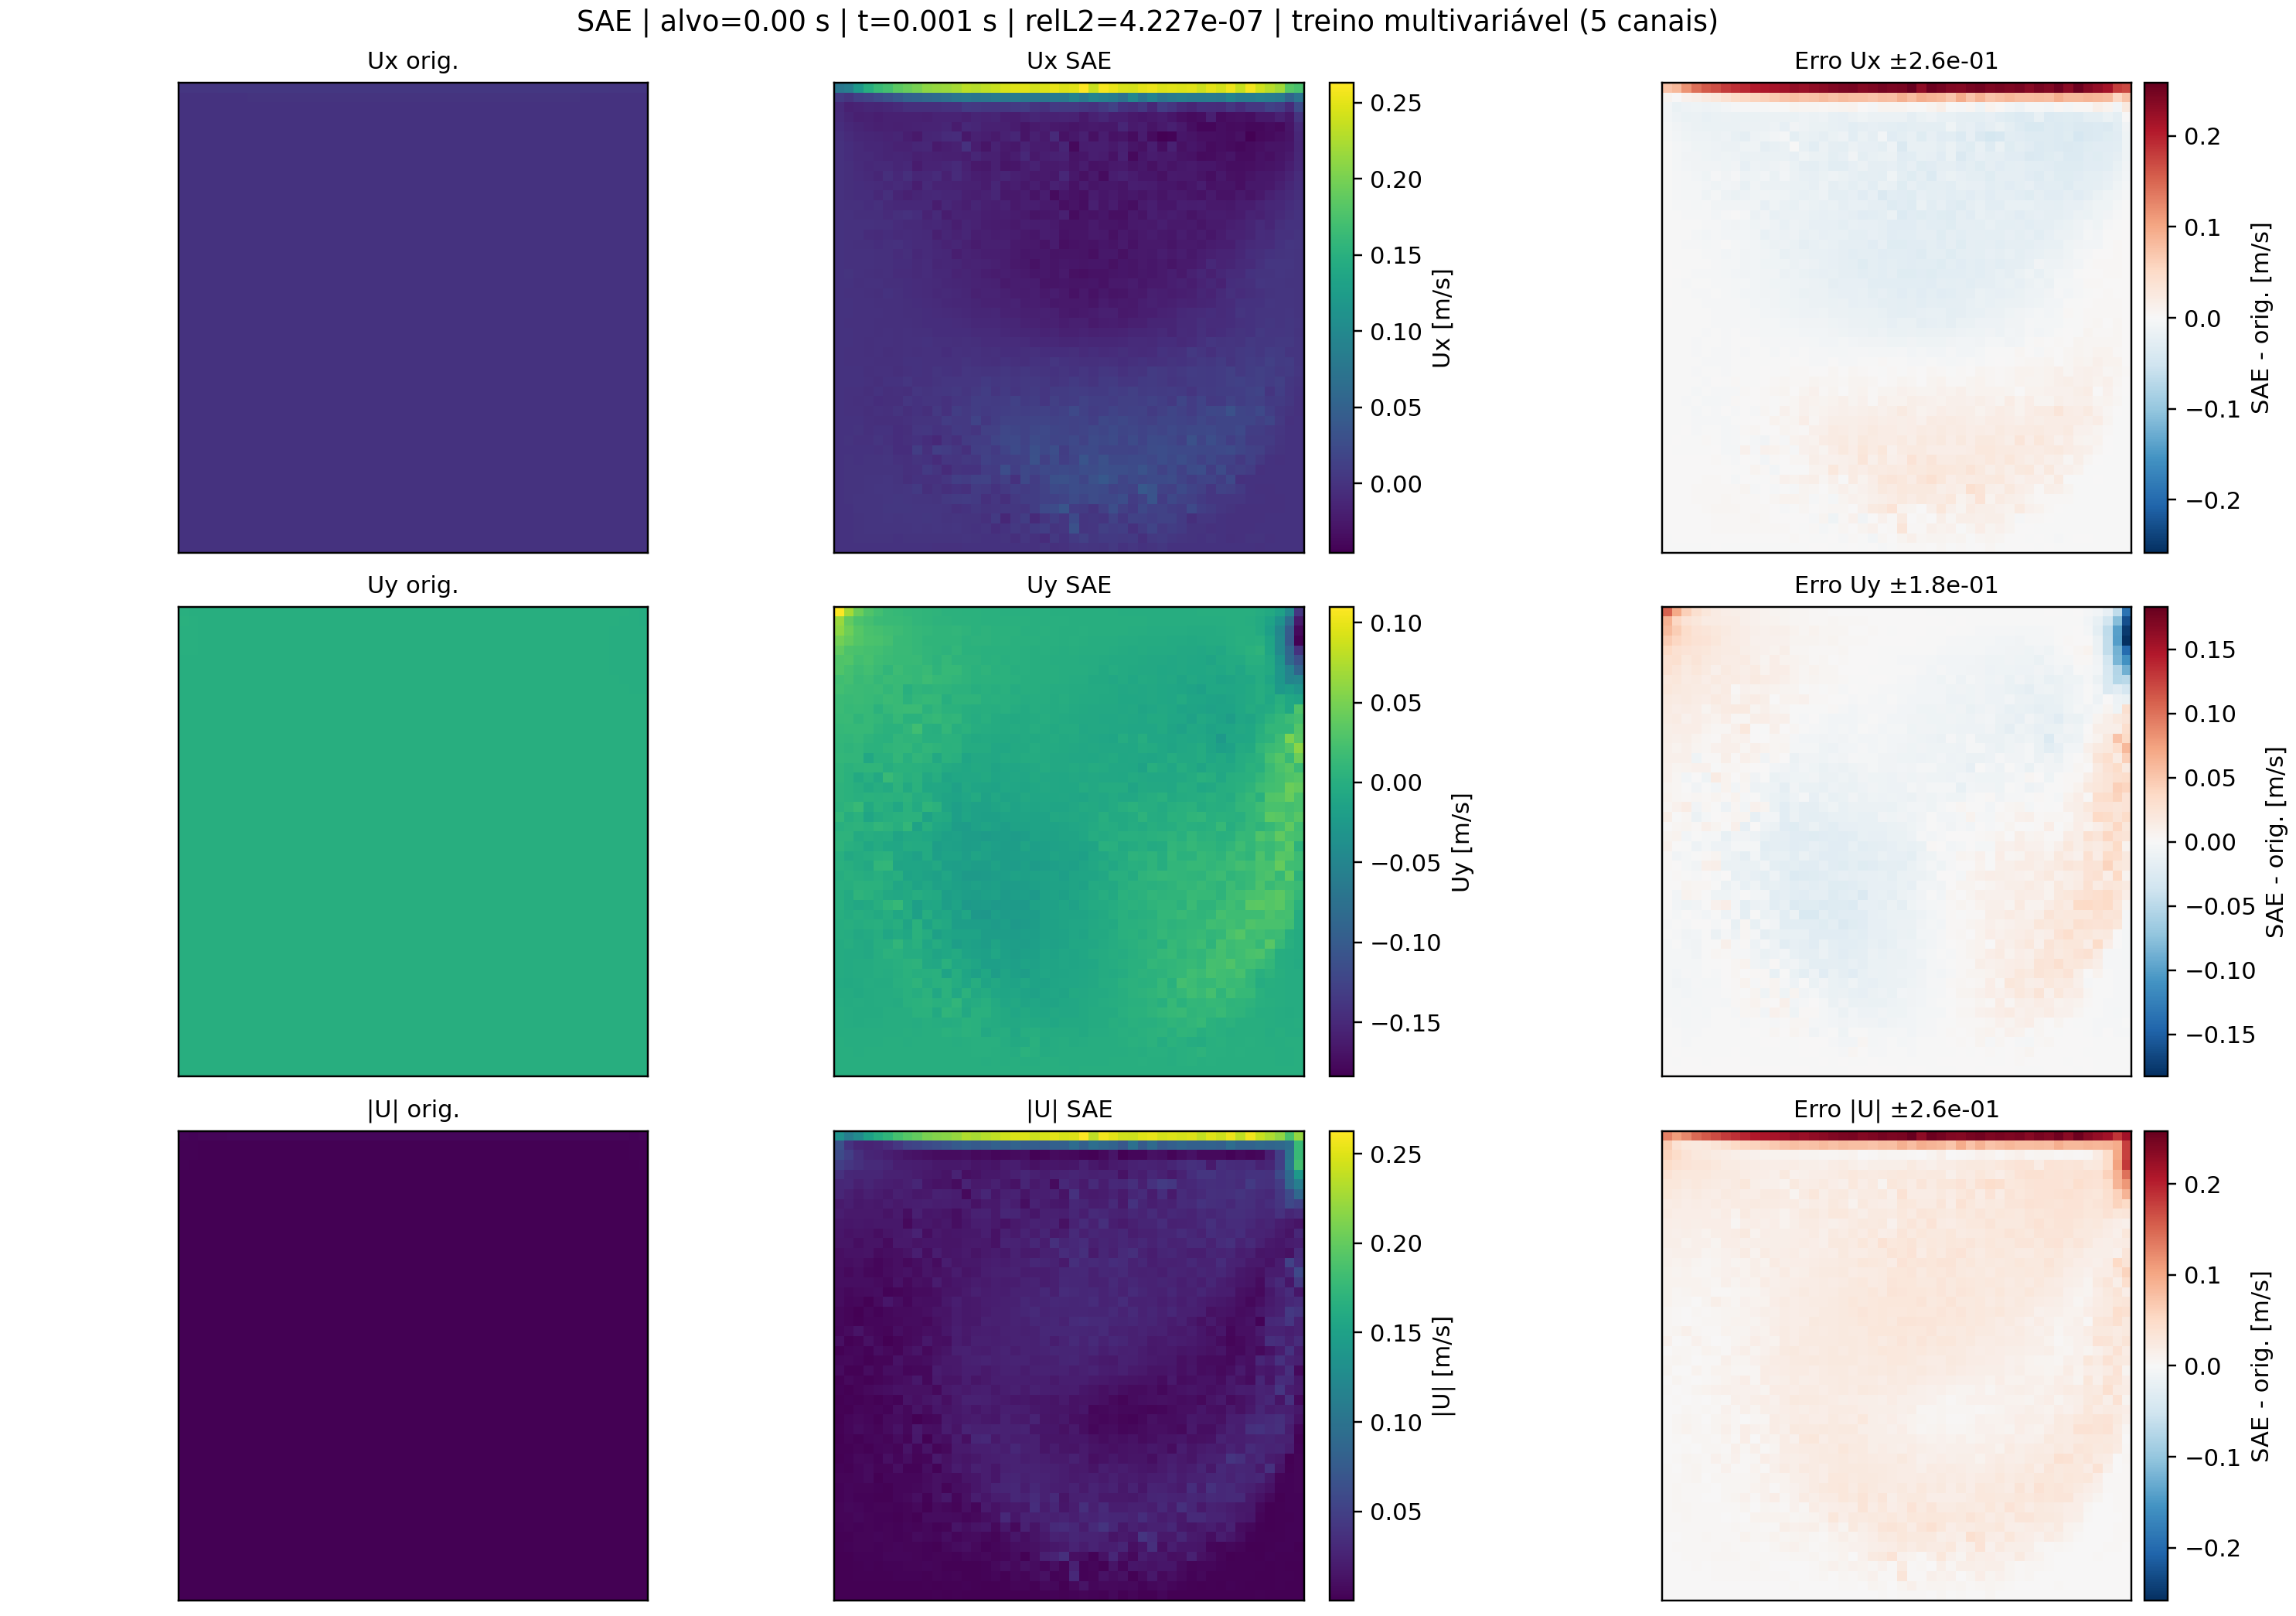

target=0.25 | split=train | idx=  32 | t_near=0.24550000 | |dt|=4.500e-03 | relL2_phys=1.648763e-07 | MSE_phys=5.436890e-05 | rank_global=52/565


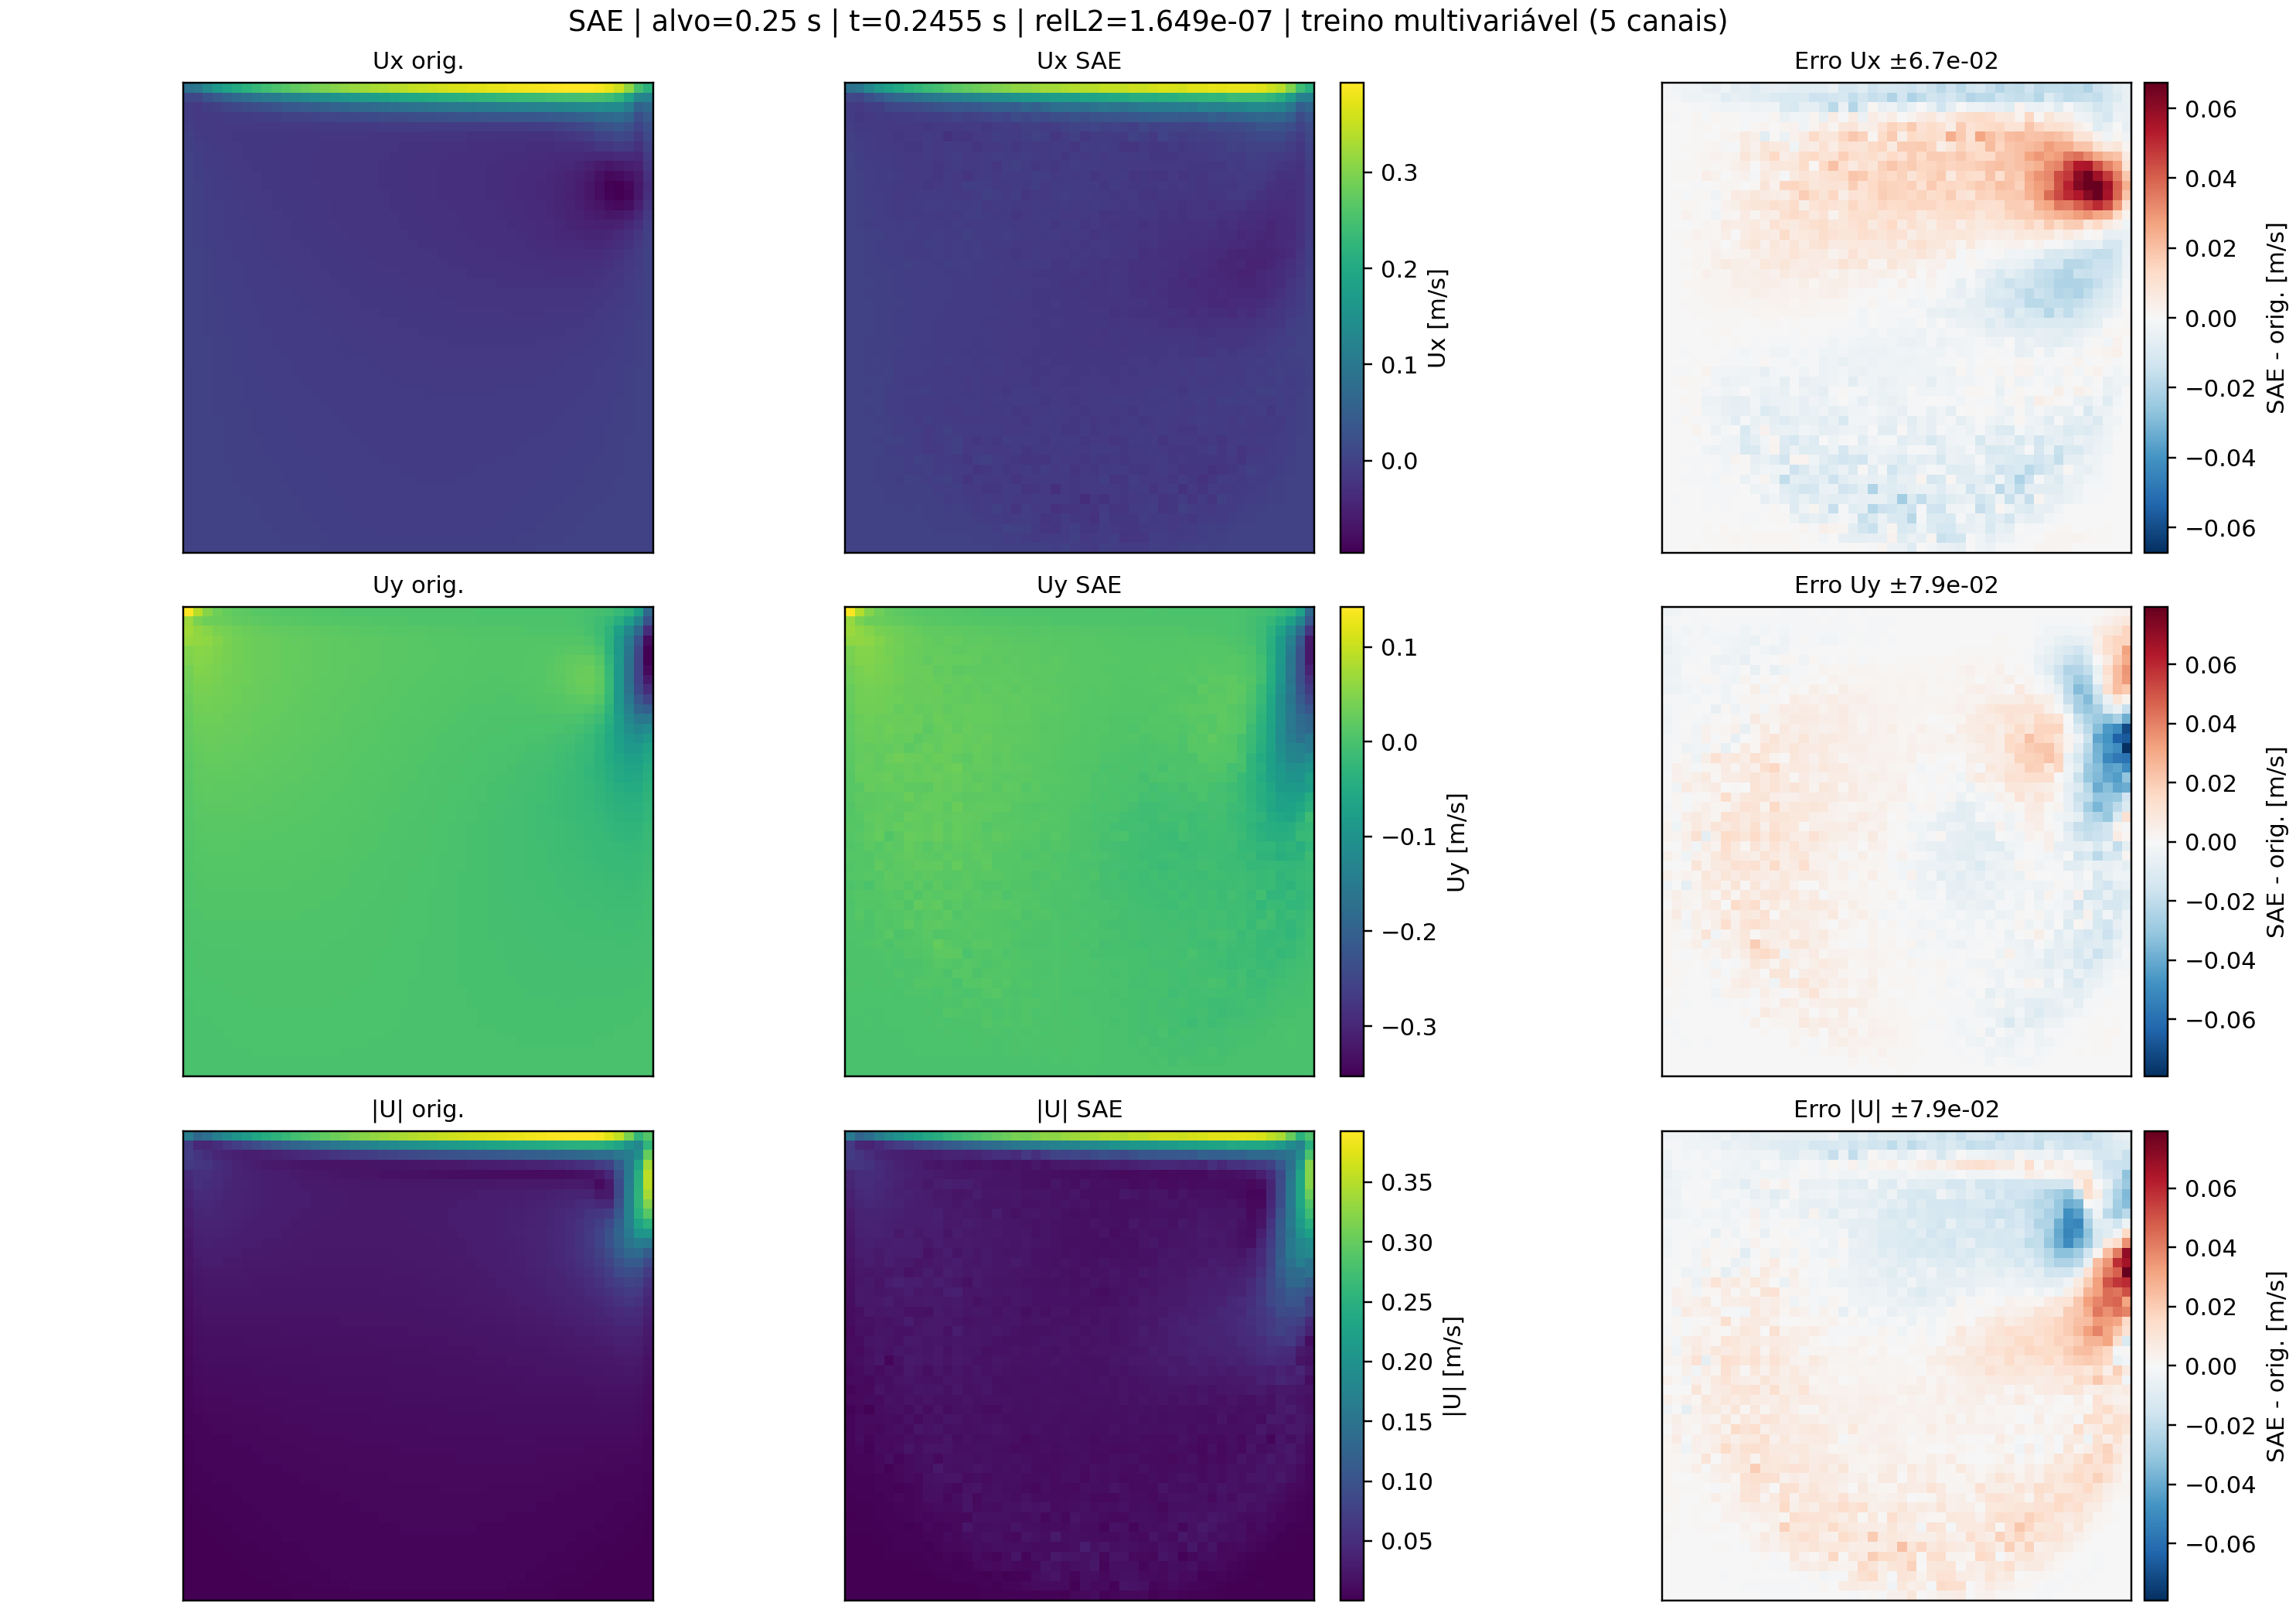

target=0.75 | split=train | idx=  93 | t_near=0.75250000 | |dt|=2.500e-03 | relL2_phys=1.639967e-07 | MSE_phys=5.379029e-05 | rank_global=57/565


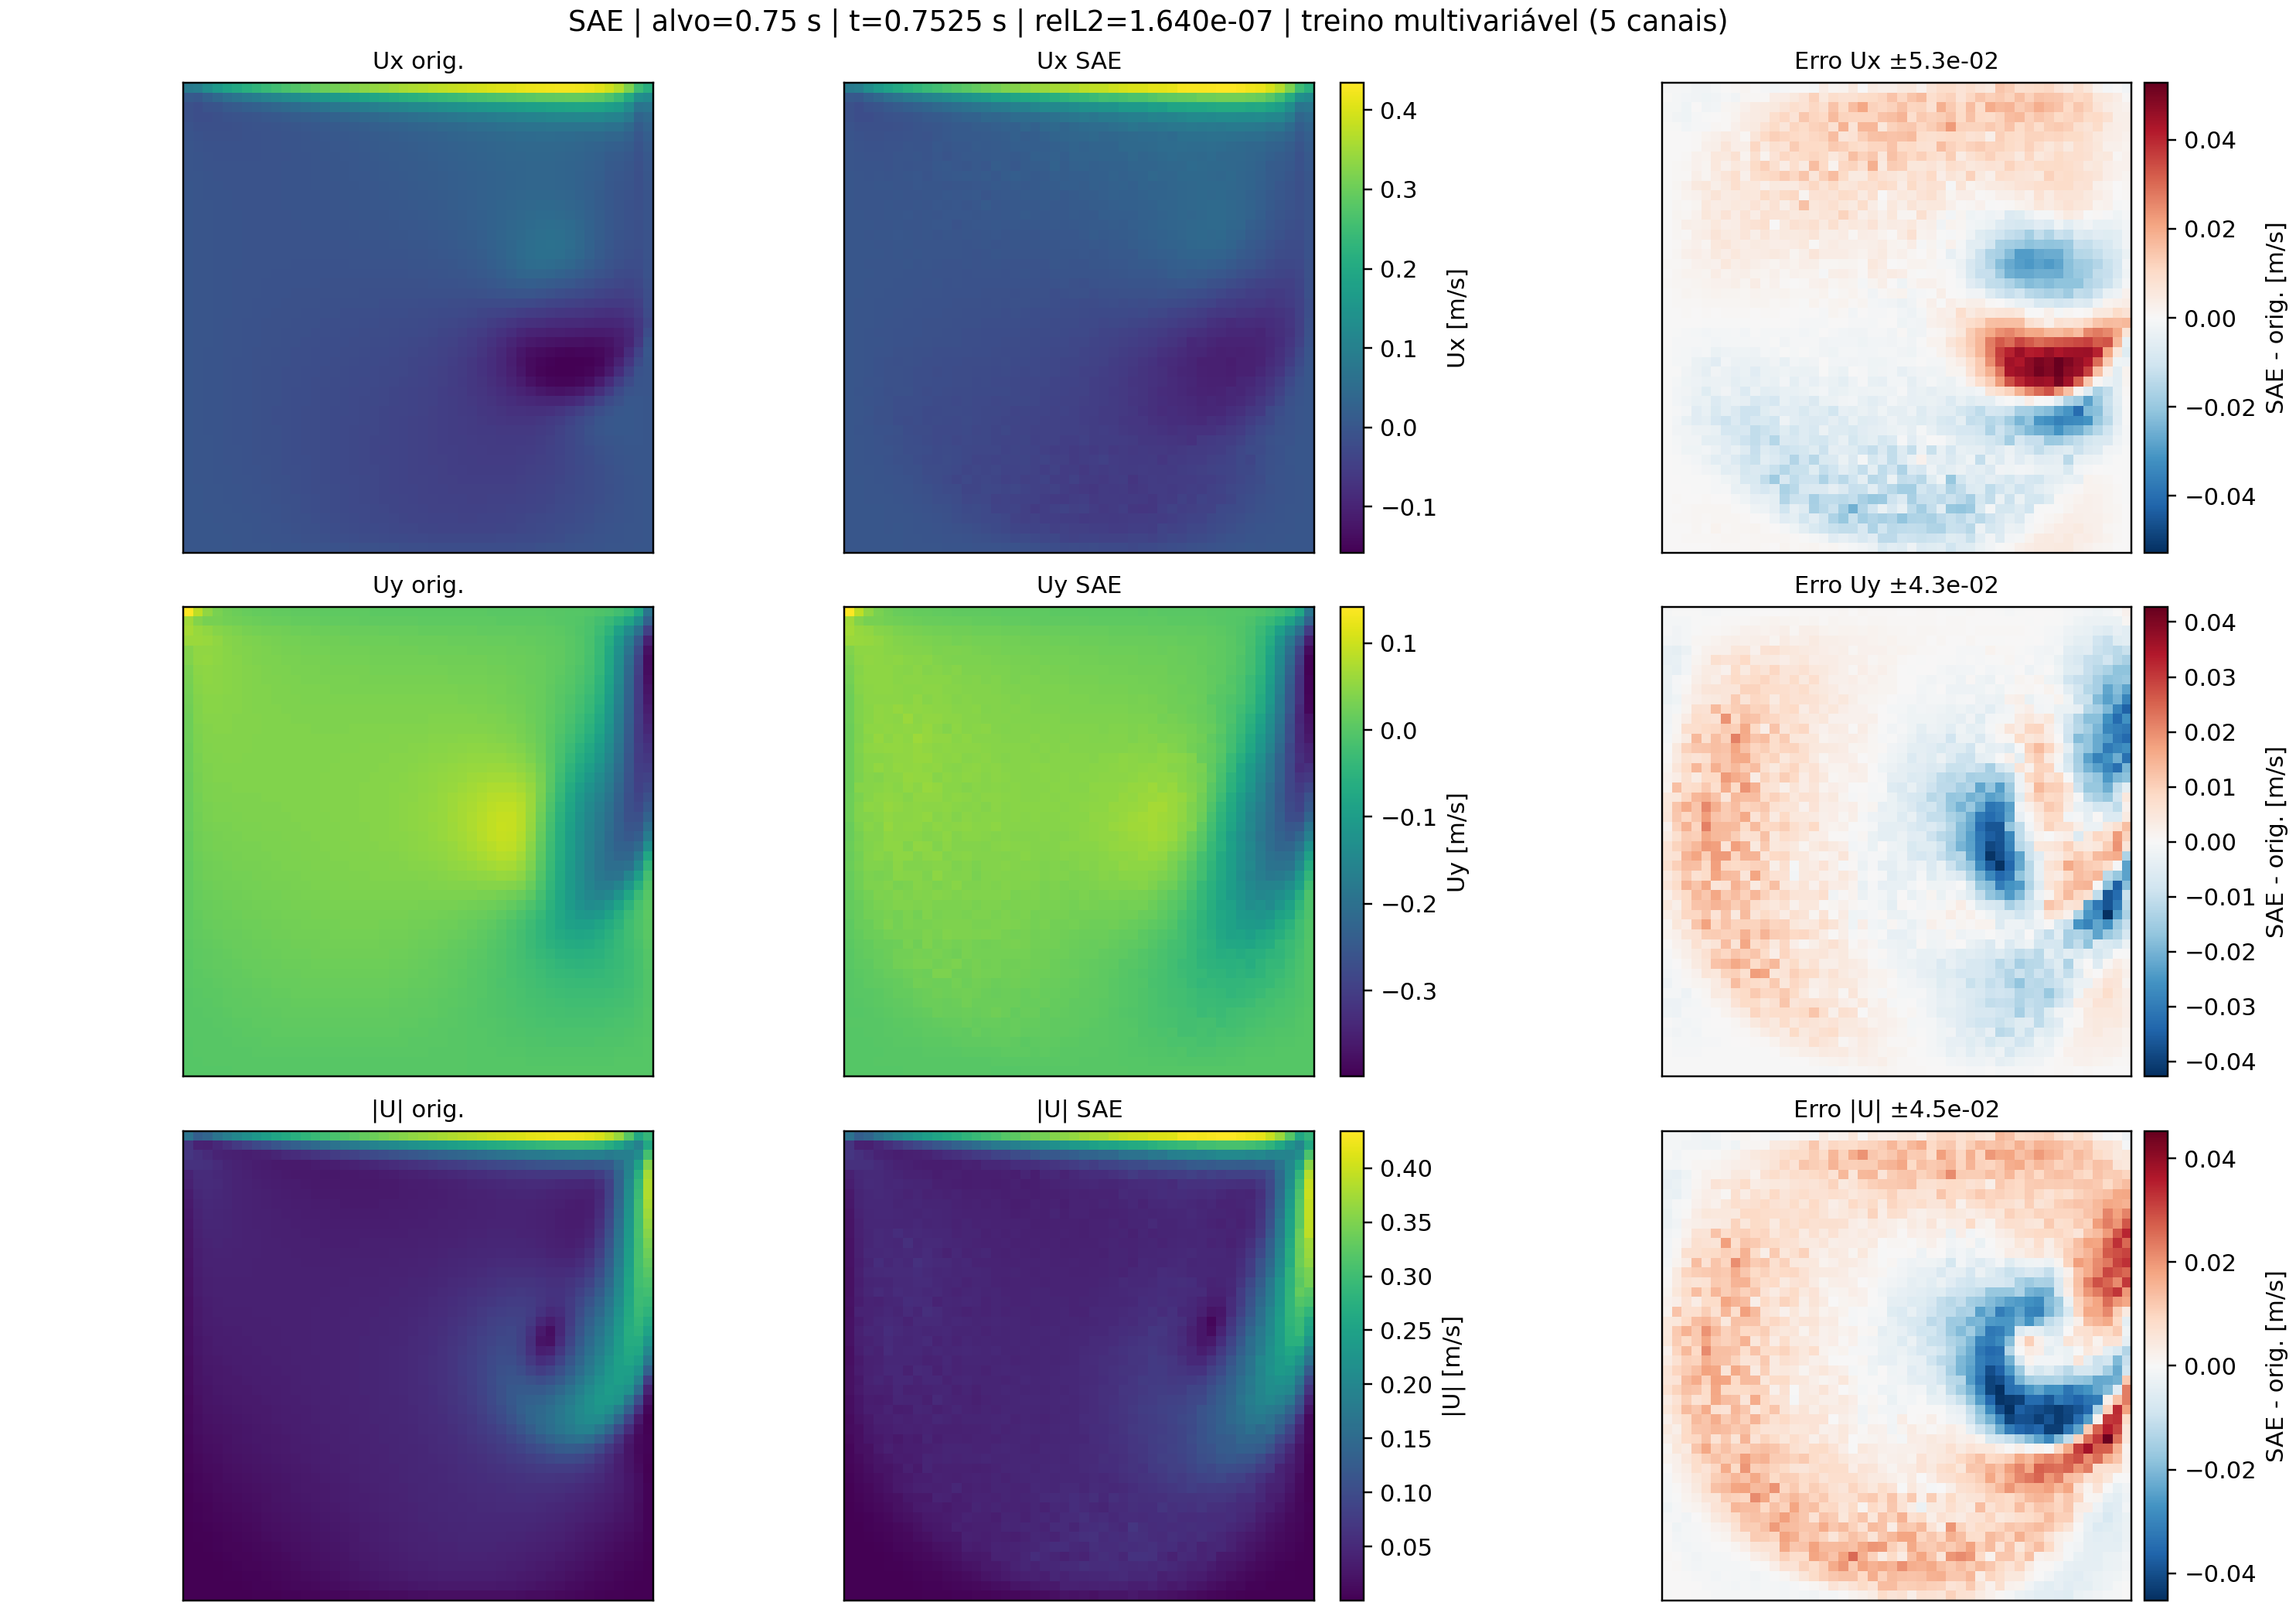

target=0.50 | split=train | idx=  64 | t_near=0.49550000 | |dt|=4.500e-03 | relL2_phys=1.632671e-07 | MSE_phys=5.331275e-05 | rank_global=61/565


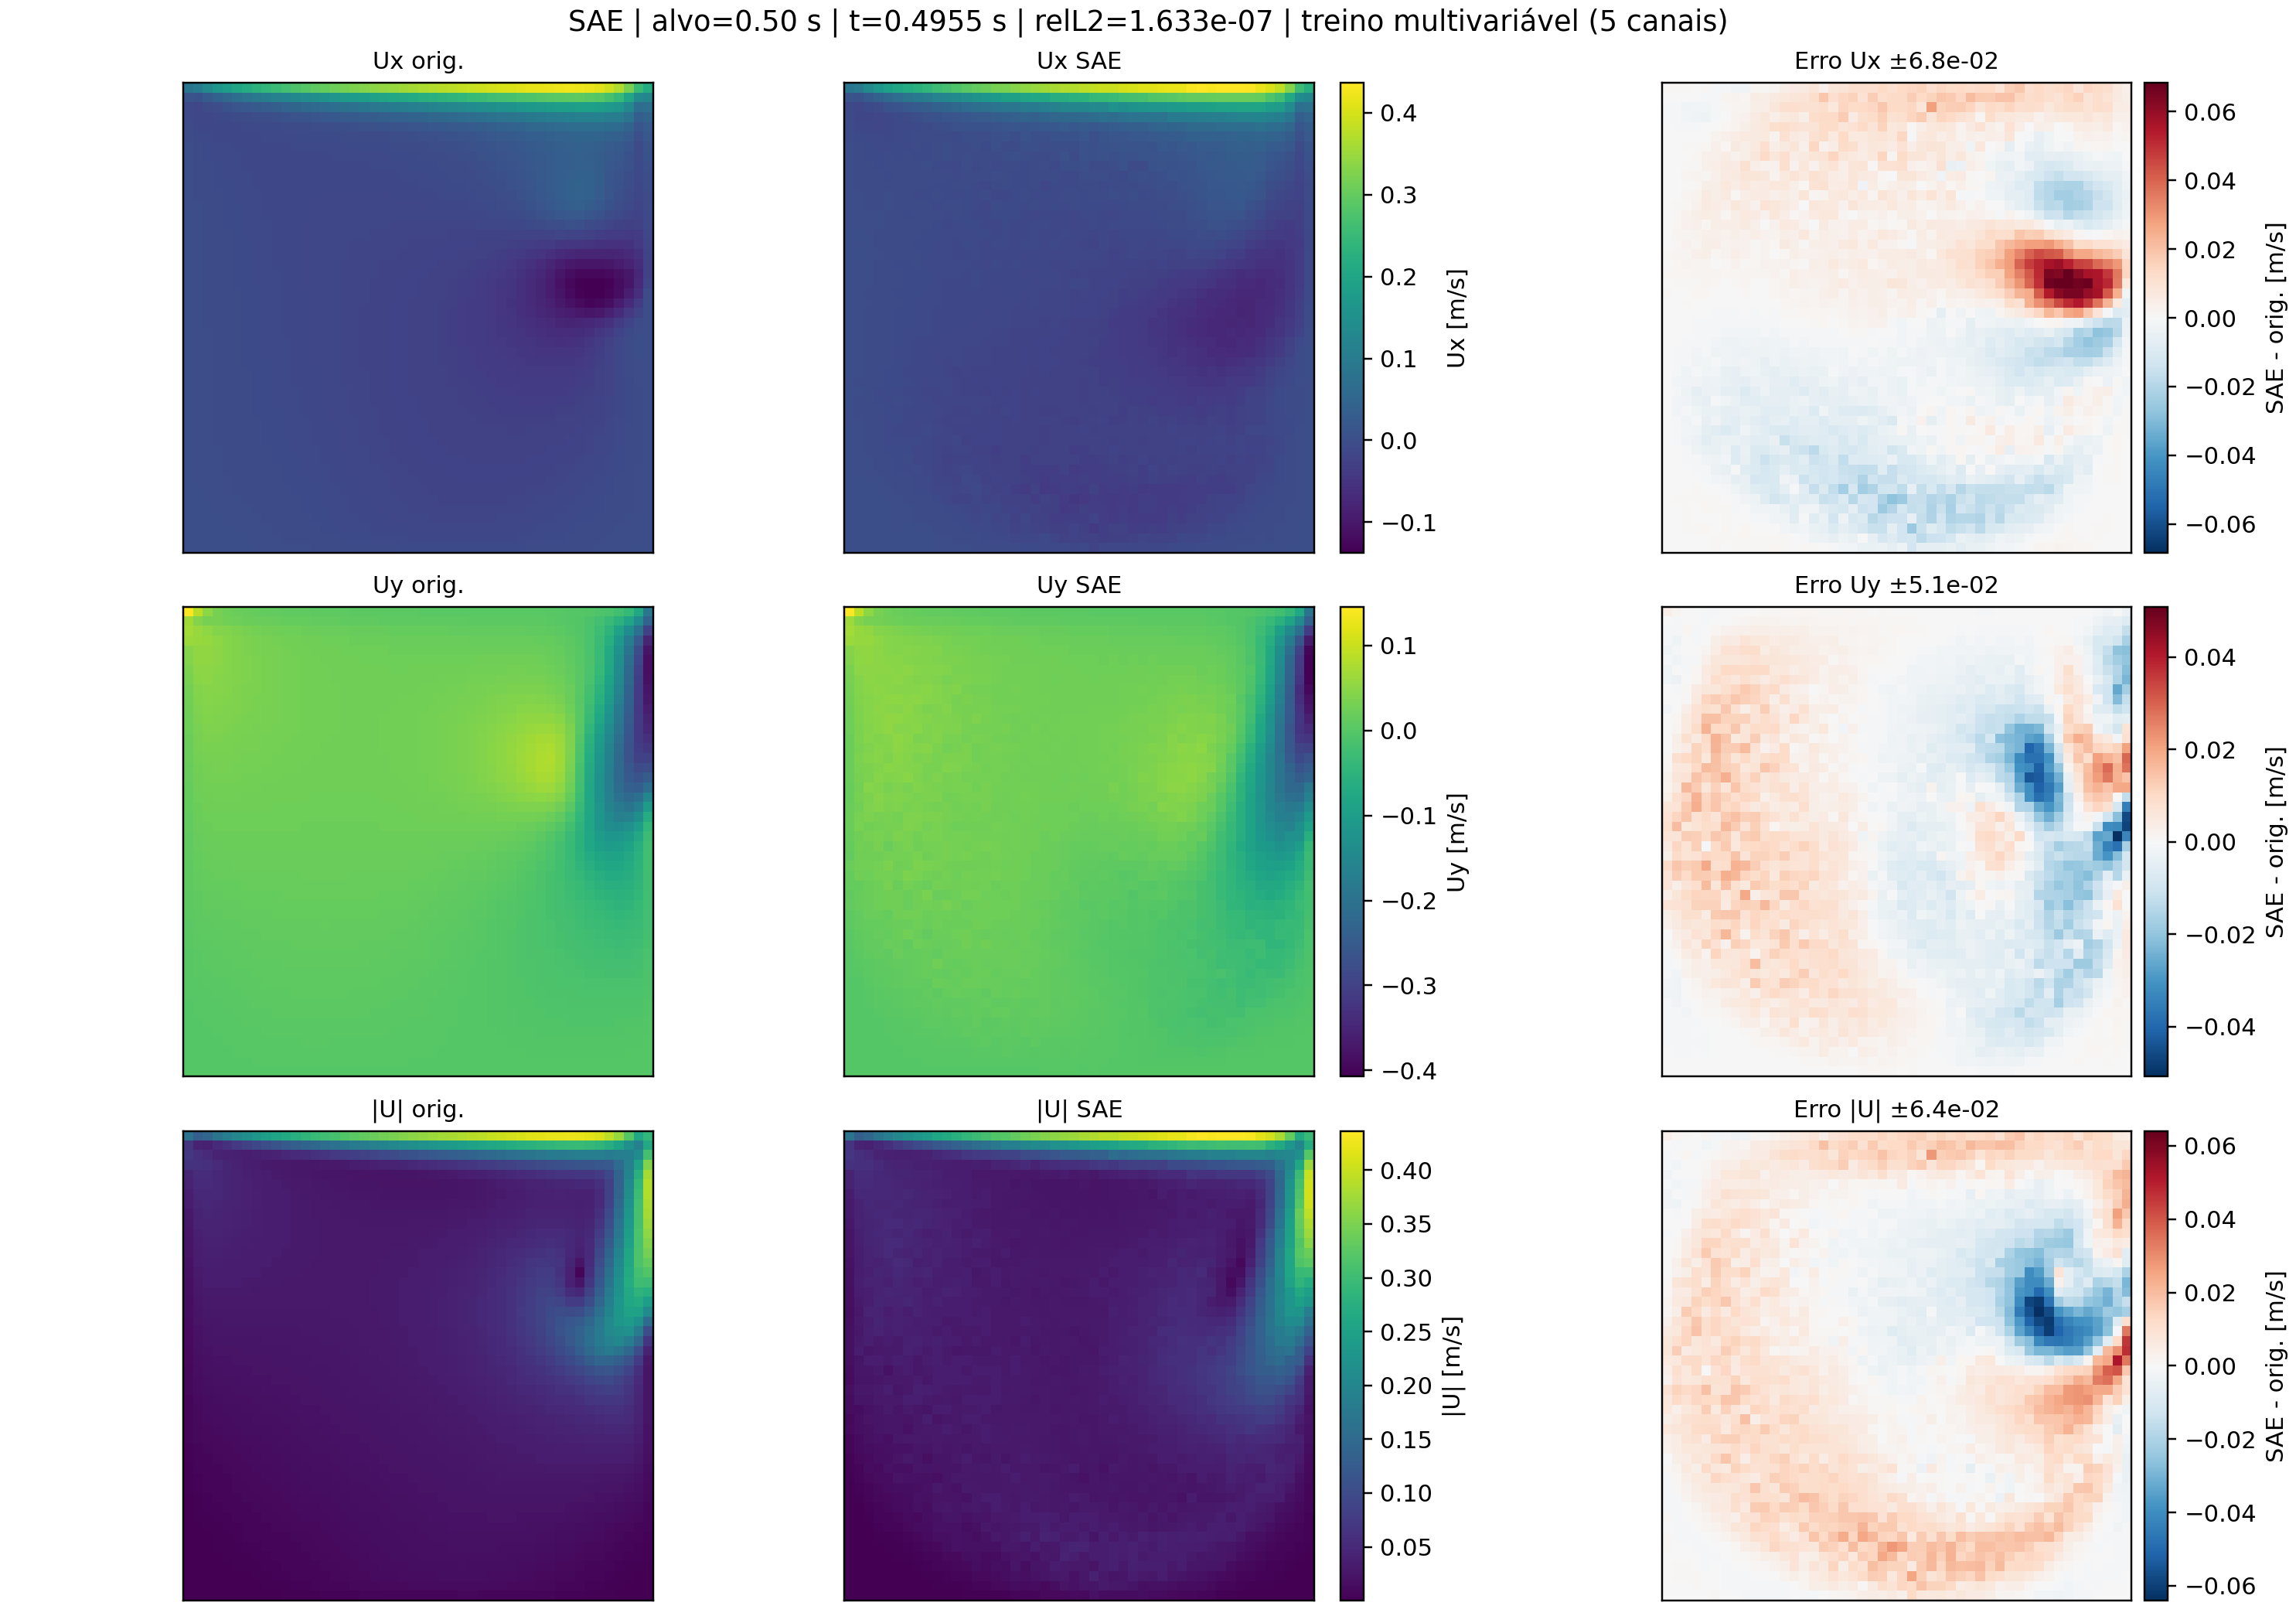

target=1.00 | split=train | idx= 123 | t_near=1.00150001 | |dt|=1.500e-03 | relL2_phys=1.308303e-07 | MSE_phys=3.423344e-05 | rank_global=190/565


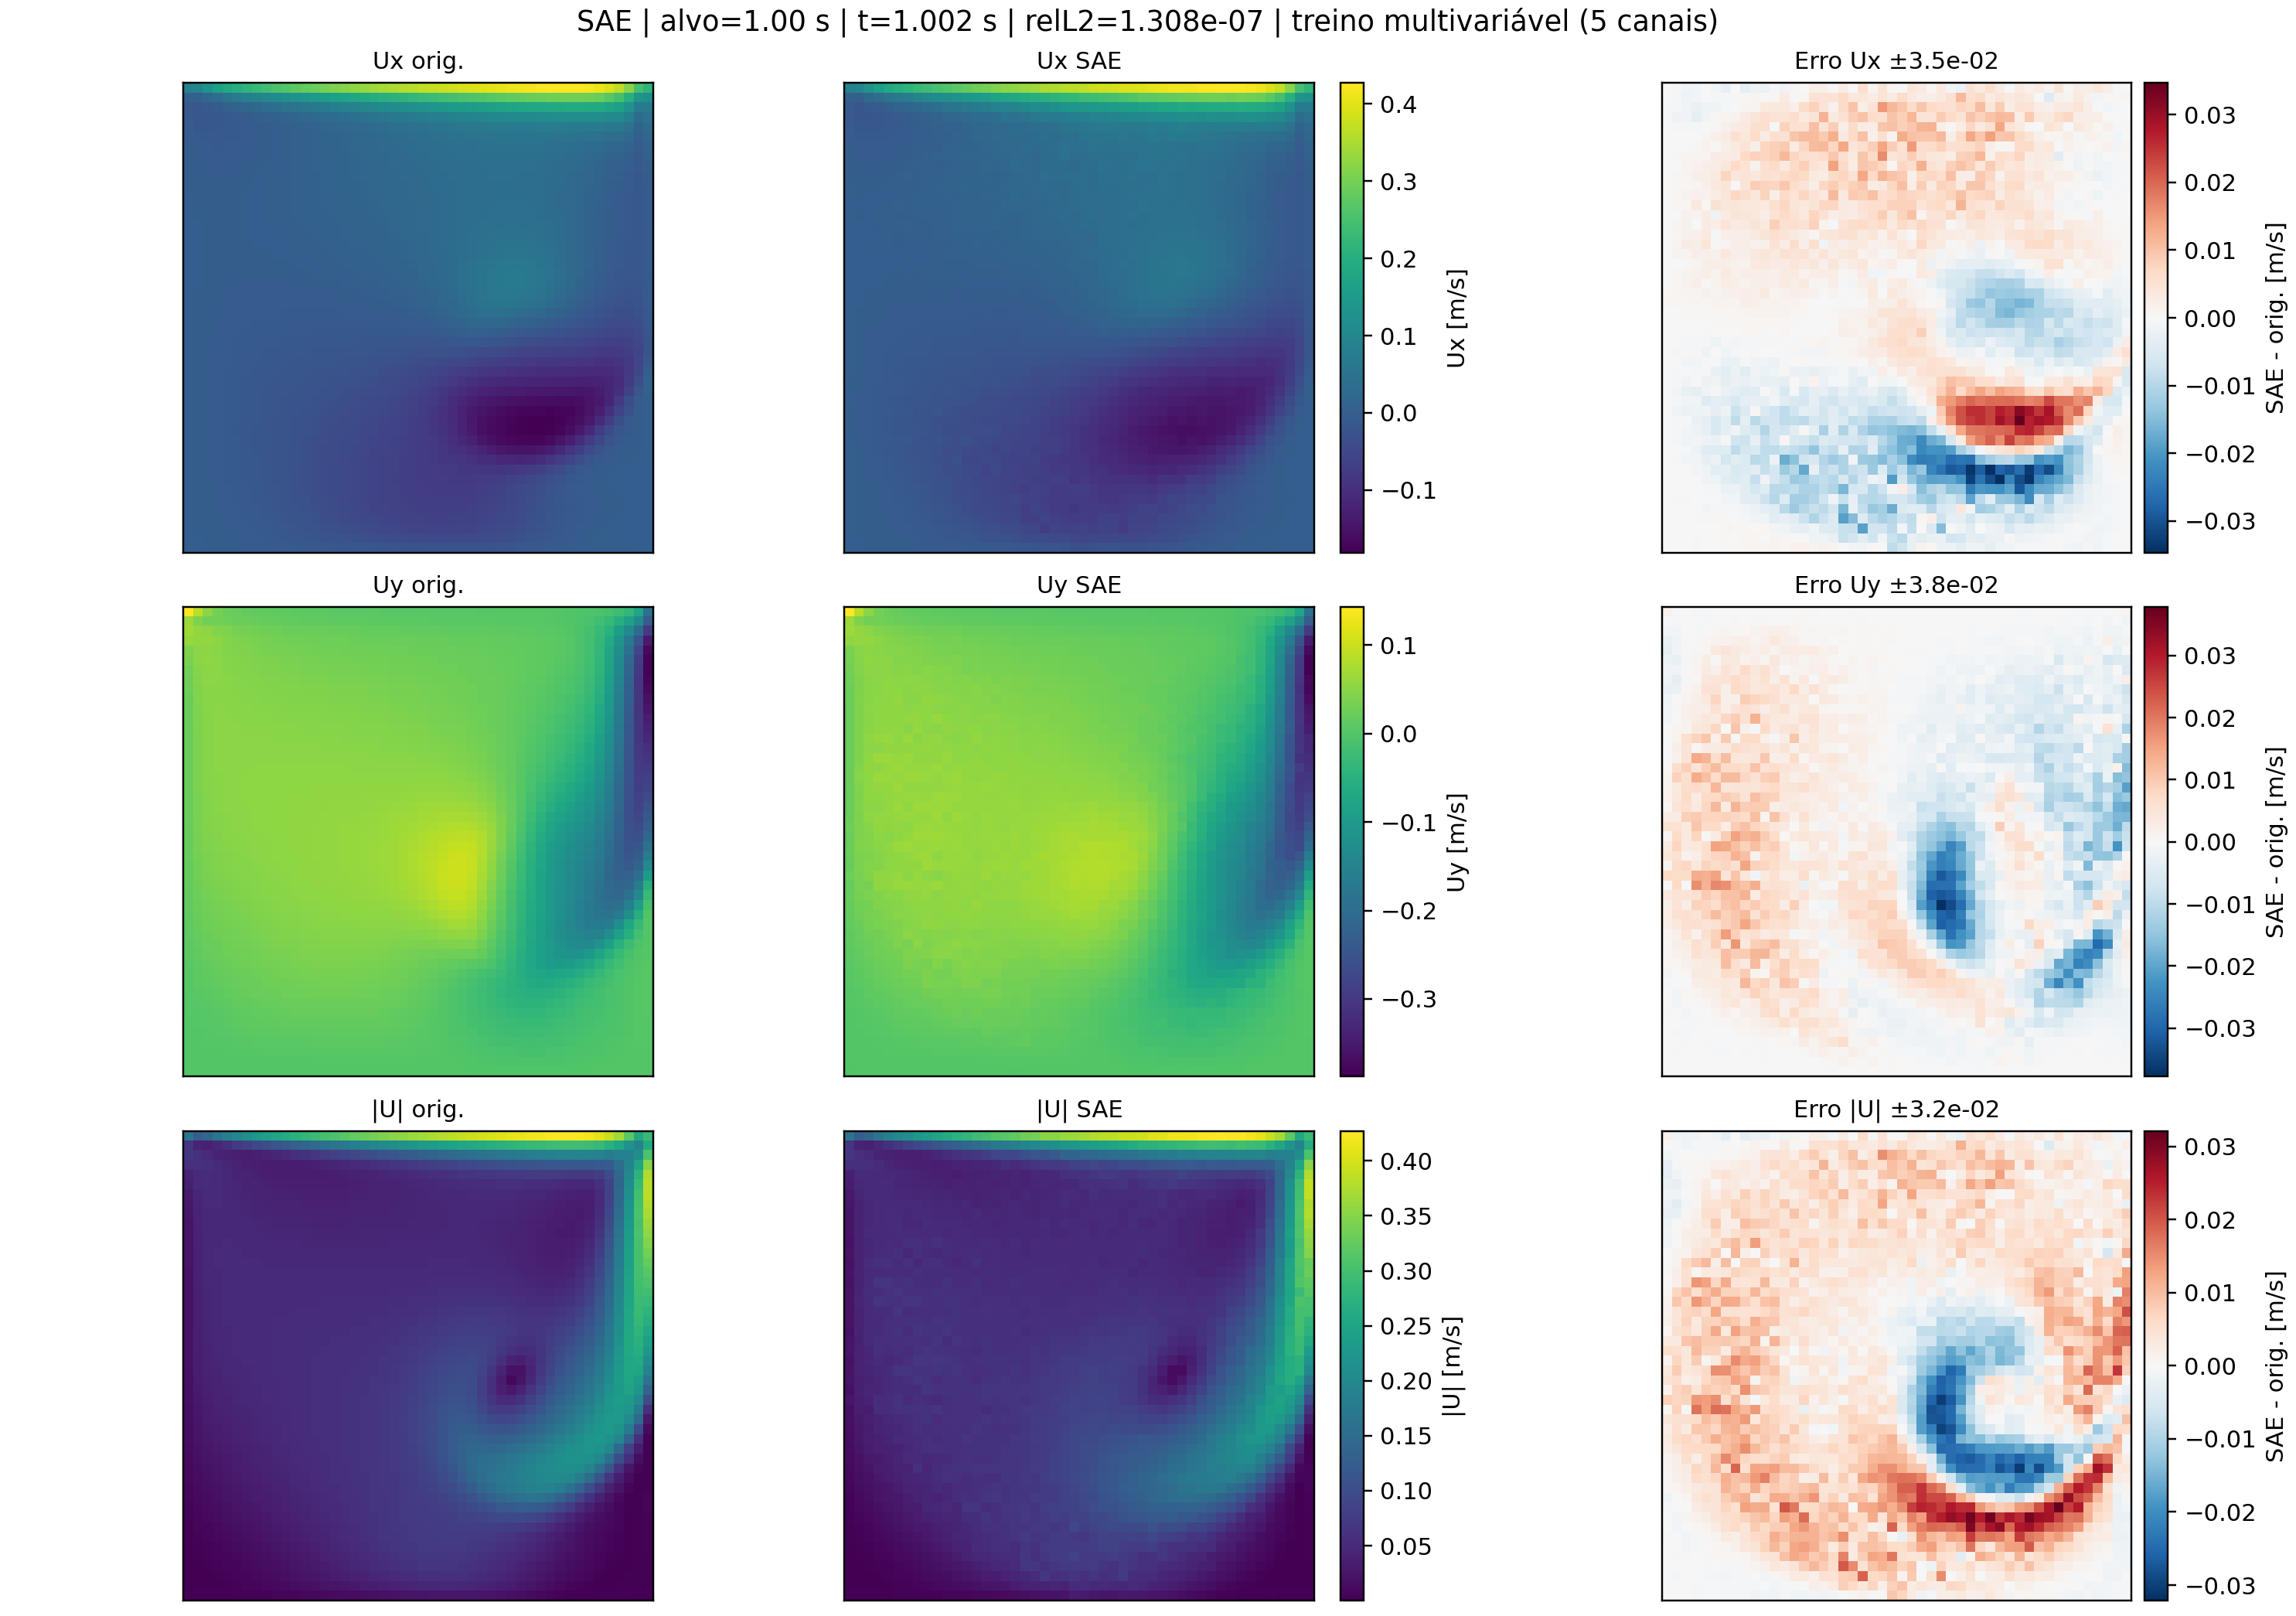

[{'target': 0.0,
  'split': 'train',
  'idx': 0,
  't_near': 0.0010000000474974513,
  'dt': 0.0010000000474974513,
  'relL2_phys': 4.226638911773484e-07,
  'mse_phys': 0.00035729274541612416,
  'rank_global': 1},
 {'target': 0.25,
  'split': 'train',
  'idx': 32,
  't_near': 0.24549999833106995,
  'dt': 0.004500001668930054,
  'relL2_phys': 1.6487633969442253e-07,
  'mse_phys': 5.4368903043302156e-05,
  'rank_global': 52},
 {'target': 0.75,
  'split': 'train',
  'idx': 93,
  't_near': 0.7524999976158142,
  'dt': 0.002499997615814209,
  'relL2_phys': 1.6399665887093102e-07,
  'mse_phys': 5.37902908324583e-05,
  'rank_global': 57},
 {'target': 0.5,
  'split': 'train',
  'idx': 64,
  't_near': 0.49549999833106995,
  'dt': 0.004500001668930054,
  'relL2_phys': 1.632670726166815e-07,
  'mse_phys': 5.3312752232173666e-05,
  'rank_global': 61},
 {'target': 1.0,
  'split': 'train',
  'idx': 123,
  't_near': 1.0015000104904175,
  'dt': 0.0015000104904174805,
  'relL2_phys': 1.3083029496606037e-

In [16]:
from IPython.display import Image, display

# ============================================================
# Figuras SAE nos tempos alvo e ranking de erro
# ============================================================

target_times = [0.0, 0.25, 0.5, 0.75, 1.0]

def print_outliers_for_target_times(
    target_times: list[float],
    t_train: np.ndarray,
    t_val: np.ndarray,
    X_train_raw: np.ndarray,
    X_val_raw: np.ndarray,
    X_train_hat_n: np.ndarray,
    X_val_hat_n: np.ndarray,
    mu: np.ndarray,
    sig: np.ndarray,
    ny: int,
    nx: int,
    out_dir: Path,
):
    mu_vec = np.asarray(mu, dtype=float).reshape(1, -1)
    sig_vec = np.asarray(sig, dtype=float).reshape(1, -1)

    X_train_hat_phys = np.asarray(X_train_hat_n, dtype=float) * sig_vec + mu_vec
    X_val_hat_phys = np.asarray(X_val_hat_n, dtype=float) * sig_vec + mu_vec

    t_all = np.concatenate([np.asarray(t_train, dtype=float), np.asarray(t_val, dtype=float)])
    split_all = np.array(["train"] * len(t_train) + ["val"] * len(t_val), dtype=object)
    X_true_all = np.vstack([np.asarray(X_train_raw, dtype=float), np.asarray(X_val_raw, dtype=float)])
    X_hat_all = np.vstack([X_train_hat_phys, X_val_hat_phys])

    rel_all = rel_l2_per_sample(X_hat_all, X_true_all)
    mse_all = mse_per_sample(X_hat_all, X_true_all)

    order = np.argsort(-rel_all)
    rank_all = np.empty_like(order)
    rank_all[order] = np.arange(1, len(rel_all) + 1)

    selected = []
    for target in target_times:
        idx = int(np.argmin(np.abs(t_all - float(target))))
        selected.append({
            "target": float(target),
            "split": str(split_all[idx]),
            "idx": idx,
            "t_near": float(t_all[idx]),
            "dt": float(abs(t_all[idx] - float(target))),
            "relL2_phys": float(rel_all[idx]),
            "mse_phys": float(mse_all[idx]),
            "rank_global": int(rank_all[idx]),
        })

    selected = sorted(selected, key=lambda row: row["relL2_phys"], reverse=True)

    outlier_dir = Path(out_dir) / "outliers_target_times"
    outlier_dir.mkdir(parents=True, exist_ok=True)

    print("\n======= OUTLIERS NOS TEMPOS-ALVO =======")
    print("Ranking de erro relativo entre os tempos alvo (maior -> menor):")

    for row in selected:
        print(
            f"target={row['target']:.2f} | split={row['split']:<5} | "
            f"idx={row['idx']:>4d} | t_near={row['t_near']:.8f} | "
            f"|dt|={row['dt']:.3e} | relL2_phys={row['relL2_phys']:.6e} | "
            f"MSE_phys={row['mse_phys']:.6e} | rank_global={row['rank_global']}/{len(t_all)}"
        )

        fname = outlier_dir / f"sae_t_{row['target']:.2f}.png"
        save_recon_triplet_from_vector(
            X_true_all[row["idx"]],
            X_hat_all[row["idx"]],
            ny,
            nx,
            fname,
            title=(
                f"SAE | alvo={row['target']:.2f} s | t={row['t_near']:.4g} s | "
                f"relL2={row['relL2_phys']:.3e}"
            ),
        )
        display(Image(filename=str(fname)))

    print("========================================\n")
    return selected

target_outliers = print_outliers_for_target_times(
    target_times=target_times,
    t_train=t_train,
    t_val=t_val,
    X_train_raw=X_train,
    X_val_raw=X_val,
    X_train_hat_n=X_train_hat,
    X_val_hat_n=X_val_hat,
    mu=mu,
    sig=sig,
    ny=cfg.ny,
    nx=cfg.nx,
    out_dir=cfg.out_dir,
)

target_outliers


In [17]:
# ============================================================
# Painel temporal SAE com três imagens na linha superior e duas na inferior
# com recorte suave e fundo cinza uniforme
# contraste apenas entre as imagens e o fundo
# ============================================================
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import FancyBboxPatch

# Usa automaticamente a pasta gerada pela célula anterior.
if "cfg" in globals():
    img_dir = Path(cfg.out_dir) / "outliers_target_times"
elif "OUT_DIR" in globals():
    img_dir = Path(OUT_DIR) / "outliers_target_times"
else:
    img_dir = Path.cwd() / "outliers_target_times"

out_path = img_dir / "serie_temporal_sae_tempos_alvo.png"

if not img_dir.exists():
    raise FileNotFoundError(f"Pasta não encontrada: {img_dir}")

img_paths = sorted(img_dir.glob("sae_t_*.png"))
if not img_paths:
    raise RuntimeError(f"Nenhuma imagem 'sae_t_*.png' encontrada em: {img_dir}")

def extract_time(path: Path) -> float:
    m = re.search(r"sae_t_(\d+(?:\.\d+)?)\.png$", path.name)
    if m is None:
        return np.inf
    return float(m.group(1))

def crop_white_border_soft(
    img: np.ndarray,
    white_thr: float = 0.992,
    pad_top: int = 18,
    pad_bottom: int = 10,
    pad_left: int = 10,
    pad_right: int = 10,
) -> np.ndarray:
    arr = np.asarray(img)

    if arr.dtype.kind in "ui":
        arr = arr.astype(np.float32) / 255.0
    else:
        arr = arr.astype(np.float32)

    if arr.ndim == 2:
        gray = arr
        alpha = np.ones_like(gray)
    elif arr.shape[2] == 4:
        gray = arr[..., :3].mean(axis=2)
        alpha = arr[..., 3]
    else:
        gray = arr[..., :3].mean(axis=2)
        alpha = np.ones_like(gray)

    mask = (gray < white_thr) & (alpha > 1e-6)

    if not np.any(mask):
        return img

    ys, xs = np.where(mask)
    y0 = max(int(ys.min()) - pad_top, 0)
    y1 = min(int(ys.max()) + pad_bottom + 1, arr.shape[0])
    x0 = max(int(xs.min()) - pad_left, 0)
    x1 = min(int(xs.max()) + pad_right + 1, arr.shape[1])

    return img[y0:y1, x0:x1]

img_paths = sorted(img_paths, key=extract_time)
times = [extract_time(p) for p in img_paths]

if len(img_paths) != 5:
    raise RuntimeError(
        f"Este bloco foi feito para 5 imagens. Encontradas: {len(img_paths)} em {img_dir}"
    )

print("Imagens encontradas em ordem temporal:")
for p, tt in zip(img_paths, times):
    print(f"  t={tt:.2f} -> {p.name}")

cropped_images = [
    crop_white_border_soft(
        mpimg.imread(p),
        white_thr=0.992,
        pad_top=18,
        pad_bottom=10,
        pad_left=10,
        pad_right=10,
    )
    for p in img_paths
]

bg_color = "#d9d9d9"

fig = plt.figure(figsize=(18, 12), facecolor=bg_color)
gs = fig.add_gridspec(2, 6)

axes = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6]),
    fig.add_subplot(gs[1, 1:3]),
    fig.add_subplot(gs[1, 3:5]),
]

for ax, img, tt in zip(axes, cropped_images, times):
    card = FancyBboxPatch(
        (-0.04, -0.04), 1.08, 1.08,
        boxstyle="round,pad=0.02",
        transform=ax.transAxes,
        facecolor=bg_color,
        edgecolor="none",
        zorder=-10,
        clip_on=False,
    )
    ax.add_patch(card)

    ax.imshow(img)
    ax.set_title(f"t = {tt:.2f}", fontsize=18, pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor(bg_color)

    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle("SAE: série temporal dos estados", fontsize=24, y=0.985)

plt.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.90,
    bottom=0.04,
    wspace=0.10,
    hspace=0.16,
)

fig.savefig(
    out_path,
    dpi=220,
    bbox_inches="tight",
    pad_inches=0.04,
    facecolor=fig.get_facecolor(),
)
display(fig)
plt.close(fig)

print(f"\nPainel temporal salvo: {out_path}")


Imagens encontradas em ordem temporal:
  t=0.00 -> sae_t_0.00.png
  t=0.25 -> sae_t_0.25.png
  t=0.50 -> sae_t_0.50.png
  t=0.75 -> sae_t_0.75.png
  t=1.00 -> sae_t_1.00.png


<Figure size 1800x1200 with 5 Axes>


Painel temporal salvo: /home/mlep-pc-ubuntu/OpenFOAM/mlep-pc-ubuntu-13/run/cavity 10 000/Codigos Cavity 10.000/SAE/resultados/outliers_target_times/serie_temporal_sae_tempos_alvo.png
